# 06 Matched Width and M4 Mechanism Analysis

## 1. Purpose and Analysis Contract

Notebook 05 established and froze the primary M1–M4 conformal prediction experiment for BERT and SpanNER. The present notebook does not introduce a new primary conformal method. Instead, it performs targeted analyses designed to explain two aspects of the frozen results.

First, the architectures use different native candidate supports. BERT considers all contiguous original-word spans, whereas SpanNER is restricted to spans of width ≤4. A matched-width conformal control therefore restricts the BERT candidate universe to width ≤4 and compares both architectures under equivalent typed-span support.

This control is distinct from the earlier width≤4 NER comparison in Notebook 03. Notebook 03 evaluated model precision, recall and F1 after restricting the evaluable entity population. Here, the restriction is applied to the **conformal candidate universe**, after which boundary ranks and conformal thresholds must be recomputed.

Second, the notebook examines the mechanism of the uncertainty-adaptive M4 score:

$$a_M4 = (1 − c) + ½[λₛ(1 − uₛ)Rₛ + λₑ(1 − uₑ)Rₑ]$$

relative to the fixed M3 formulation:

$$a_M3 = (1 − c) + ½(λₛRₛ + λₑRₑ)$$.

For a fixed candidate and fixed λ values, the direct score reduction introduced by M4 is:

$$Δ = a_M3 − a_M4 = ½(λₛuₛRₛ + λₑuₑRₑ)$$.

The mechanism analysis therefore asks **which candidates receive this relaxation**, whether they are gold or non-gold candidates, how relaxation interacts with candidate confidence, and why the adaptive formulation can produce larger prediction sets at demanding coverage levels.

The experimental contract is fixed as follows:

- **No λ values are retuned.** All M1–M4 parameters are inherited from Notebook 05.
- **Temperature scaling remains frozen** at the Notebook-04 values propagated through Notebook 05.
- **Binary boundary-correctness calibrators remain secondary diagnostics** and do not enter M1–M4.
- **MC Dropout does not enter the conformal mechanism analysis.**
- The matched-width control restricts BERT to **width ≤4**, then recomputes candidate-local start/end ranks and conformal thresholds on the restricted universe.
- SpanNER already has width≤4 support and is not artificially modified.
- The primary matched-width comparison retains the same 90%, 95% and 99% conformal operating points.
- Mechanism diagnostics use the frozen validation population and do not alter the primary conformal specification.
- **M5 is considered only as an exploratory validation diagnostic.** It is not promoted to the primary M1–M4 method family and does not replace M4 downstream.
- The official CoNLL-2003 test set remains locked and is not accessed in this notebook.

The purpose of these analyses is explanatory rather than corrective. The objective is not to modify M4 until it performs better, but to determine why its coverage–efficiency behaviour differs from the fixed alternatives.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Fixed analysis design inherited from the completed conformal experiment.
SEED = 42

VALIDATION_SENTENCES = 1625
CONFORMAL_CALIBRATION_SENTENCES = 650

MATCHED_MAX_WIDTH = 4
TARGET_COVERAGES = (0.90, 0.95, 0.99)

PRIMARY_METHODS = ("M1", "M2", "M3", "M4")

# M5 is retained only as a post-hoc mechanism diagnostic.
EXPLORATORY_METHODS = ("M5",)

# Notebook 06 must not modify the primary conformal specification.
LAMBDA_RETUNING_PERMITTED = False
BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4 = False
MC_DROPOUT_USED_IN_MECHANISM_ANALYSIS = False
OFFICIAL_TEST_ACCESSED = False


analysis_contract = {
    "seed": SEED,
    "validation_sentences": VALIDATION_SENTENCES,
    "conformal_calibration_sentences": CONFORMAL_CALIBRATION_SENTENCES,
    "matched_candidate_max_width": MATCHED_MAX_WIDTH,
    "target_coverages": list(TARGET_COVERAGES),
    "primary_methods": list(PRIMARY_METHODS),
    "exploratory_methods": list(EXPLORATORY_METHODS),
    "lambda_retuning_permitted": LAMBDA_RETUNING_PERMITTED,
    "temperature_scaling_frozen": True,
    "binary_correctness_calibration_role": "secondary_diagnostic",
    "binary_calibrators_used_in_primary_M1_M4": (
        BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4
    ),
    "mc_dropout_used_in_mechanism_analysis": (
        MC_DROPOUT_USED_IN_MECHANISM_ANALYSIS
    ),
    "M5_status": "post_hoc_validation_diagnostic",
    "official_test_accessed": OFFICIAL_TEST_ACCESSED,
}

contract_summary_df = pd.DataFrame(
    [
        {
            "Analysis": "Matched-width conformal control",
            "Population": "Validation + conformal calibration",
            "Primary change": "Restrict BERT candidate universe to width ≤4",
            "Retuning": "None",
        },
        {
            "Analysis": "M4 mechanism diagnostics",
            "Population": "Validation",
            "Primary change": "None; analyse frozen candidate scores",
            "Retuning": "None",
        },
        {
            "Analysis": "M5 confidence-gating diagnostic",
            "Population": "Validation",
            "Primary change": "Exploratory score diagnostic only",
            "Retuning": "Not promoted to M1–M4",
        },
    ]
)

print("Notebook 06 analysis contract")
display(contract_summary_df)

print(f"\nMatched candidate maximum width: {MATCHED_MAX_WIDTH}")
print("Target coverages:", TARGET_COVERAGES)
print("Primary conformal methods:", PRIMARY_METHODS)
print("M5 status:", analysis_contract["M5_status"])
print("Lambda retuning permitted:", LAMBDA_RETUNING_PERMITTED)
print(
    "Binary correctness calibrators used in M1-M4:",
    BINARY_CALIBRATORS_USED_IN_PRIMARY_M1_M4,
)
print("Official CoNLL test accessed:", OFFICIAL_TEST_ACCESSED)

Notebook 06 analysis contract


,Analysis,Population,Primary change,Retuning
0,Matched-width conformal control,Validation + conformal calibration,Restrict BERT candidate universe to width ≤4,None
1,M4 mechanism diagnostics,Validation,None; analyse frozen candidate scores,None
2,M5 confidence-gating diagnostic,Validation,Exploratory score diagnostic only,Not promoted to M1–M4



Matched candidate maximum width: 4
Target coverages: (0.9, 0.95, 0.99)
Primary conformal methods: ('M1', 'M2', 'M3', 'M4')
M5 status: post_hoc_validation_diagnostic
Lambda retuning permitted: False
Binary correctness calibrators used in M1-M4: False
Official CoNLL test accessed: False


## 2. Frozen Conformal Handoff

Notebook 06 begins from the completed and frozen conformal specification produced by Notebook 05. No primary M1–M4 parameters are estimated again here.

The following Notebook-05 artefacts are reused:

- the final conformal specification containing the frozen temperatures, score definitions, λ configurations and conformal thresholds;
- validation candidate-component tables for BERT and SpanNER;
- conformal-calibration candidate-component tables for both architectures;
- the duplicate-safe validation fold assignment used during λ development.

The candidate-component tables contain the quantities required for the present analyses: temperature-scaled candidate confidence, base nonconformity, architecture-specific boundary uncertainty, normalized boundary ranks and gold-candidate identity.

For the matched-width control, BERT candidates will later be restricted to width ≤4 and their boundary ranks will be recomputed within that restricted candidate universe. The stored native BERT ranks are therefore retained only as the original Notebook-05 reference.

Notebook 01 is used only to recover human-readable validation tokens for selected mechanism examples. It does not provide new model estimates or conformal parameters.

In [2]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")


def find_unique_file(filename):
    """Resolve one attached Kaggle artefact by its frozen filename."""
    matches = list(
        KAGGLE_INPUT_ROOT.rglob(filename)
    )

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one '{filename}' artefact, found {len(matches)}."
        )

    return matches[0]


# Notebook 05 is the authoritative source for all primary conformal settings.
final_specification_path = find_unique_file(
    "final_conformal_specification.json"
)

validation_fold_path = find_unique_file(
    "validation_lambda_fold_assignment.csv"
)

bert_validation_components_path = find_unique_file(
    "bert_validation_conformal_components.parquet"
)

spanner_validation_components_path = find_unique_file(
    "spanner_validation_conformal_components.parquet"
)

bert_calibration_components_path = find_unique_file(
    "bert_conformal_calibration_components.parquet"
)

spanner_calibration_components_path = find_unique_file(
    "spanner_conformal_calibration_components.parquet"
)


# Notebook 01 contributes only readable token information for later examples.
bert_validation_tokens_path = find_unique_file(
    "validation_token_predictions.csv"
)


with final_specification_path.open(
    "r",
    encoding="utf-8",
) as file:
    frozen_conformal_specification = json.load(file)

validation_fold_df = pd.read_csv(
    validation_fold_path
)

bert_validation_components_df = pd.read_parquet(
    bert_validation_components_path
)

spanner_validation_components_df = pd.read_parquet(
    spanner_validation_components_path
)

bert_calibration_components_df = pd.read_parquet(
    bert_calibration_components_path
)

spanner_calibration_components_df = pd.read_parquet(
    spanner_calibration_components_path
)

bert_validation_tokens_df = pd.read_csv(
    bert_validation_tokens_path
)


# Notebook 05 must be complete and explicitly locked against downstream retuning.
if frozen_conformal_specification["status"] != (
    "M1_M4_CONFORMAL_SPECIFICATION_FROZEN"
):
    raise RuntimeError(
        "Notebook-05 conformal specification is not frozen."
    )

if frozen_conformal_specification[
    "lambda_retuning_permitted_downstream"
]:
    raise RuntimeError(
        "Notebook 05 unexpectedly permits downstream lambda retuning."
    )

if frozen_conformal_specification[
    "official_test_accessed"
]:
    raise RuntimeError(
        "Notebook-05 specification reports official test access."
    )


# Candidate-component tables should contain exactly the quantities required
# for matched-width and M4 mechanism analysis.
required_component_columns = {
    "sentence_id",
    "start",
    "end",
    "entity_type",
    "word_length",
    "base_confidence",
    "base_nonconformity",
    "start_uncertainty",
    "end_uncertainty",
    "start_rank_penalty",
    "end_rank_penalty",
    "is_gold_candidate",
}

for model_name, component_df in {
    "BERT validation": bert_validation_components_df,
    "SpanNER validation": spanner_validation_components_df,
    "BERT calibration": bert_calibration_components_df,
    "SpanNER calibration": spanner_calibration_components_df,
}.items():

    missing = (
        required_component_columns
        - set(component_df.columns)
    )

    if missing:
        raise RuntimeError(
            f"{model_name} components are missing: {sorted(missing)}"
        )


handoff_summary_df = pd.DataFrame(
    [
        {
            "Source": "Notebook 05",
            "Artefact": "BERT validation components",
            "Candidates": len(
                bert_validation_components_df
            ),
            "Sentences": bert_validation_components_df[
                "sentence_id"
            ].nunique(),
        },
        {
            "Source": "Notebook 05",
            "Artefact": "SpanNER validation components",
            "Candidates": len(
                spanner_validation_components_df
            ),
            "Sentences": spanner_validation_components_df[
                "sentence_id"
            ].nunique(),
        },
        {
            "Source": "Notebook 05",
            "Artefact": "BERT calibration components",
            "Candidates": len(
                bert_calibration_components_df
            ),
            "Sentences": bert_calibration_components_df[
                "sentence_id"
            ].nunique(),
        },
        {
            "Source": "Notebook 05",
            "Artefact": "SpanNER calibration components",
            "Candidates": len(
                spanner_calibration_components_df
            ),
            "Sentences": spanner_calibration_components_df[
                "sentence_id"
            ].nunique(),
        },
    ]
)

print("Table: Frozen Notebook-05 Handoff")
display(handoff_summary_df)

print(
    "\nBERT temperature:",
    round(
        frozen_conformal_specification[
            "temperatures"
        ]["BERT"],
        6,
    ),
)

print(
    "SpanNER temperature:",
    round(
        frozen_conformal_specification[
            "temperatures"
        ]["SpanNER"],
        6,
    ),
)

print(
    "Validation fold sentences:",
    validation_fold_df["sentence_id"].nunique(),
)

print(
    "Lambda retuning permitted:",
    frozen_conformal_specification[
        "lambda_retuning_permitted_downstream"
    ],
)

print(
    "Binary correctness calibrators used in M1-M4:",
    frozen_conformal_specification[
        "binary_calibrators_used_in_primary_M1_M4"
    ],
)

print(
    "Official CoNLL test accessed:",
    frozen_conformal_specification[
        "official_test_accessed"
    ],
)

Table: Frozen Notebook-05 Handoff


,Source,Artefact,Candidates,Sentences
0,Notebook 05,BERT validation components,1399604,1625
1,Notebook 05,SpanNER validation components,377988,1625
2,Notebook 05,BERT calibration components,522112,650
3,Notebook 05,SpanNER calibration components,138540,650



BERT temperature: 1.264385
SpanNER temperature: 1.466519
Validation fold sentences: 1625
Lambda retuning permitted: False
Binary correctness calibrators used in M1-M4: False
Official CoNLL test accessed: False


In [3]:
# AUDIT — Verify official Notebook-05 frozen conformal handoff

# 1. Ensure all Notebook-05 artefacts came from ONE output root

notebook05_paths = [
    final_specification_path,
    validation_fold_path,
    bert_validation_components_path,
    spanner_validation_components_path,
    bert_calibration_components_path,
    spanner_calibration_components_path,
]

notebook05_roots = {
    path.parents[1]
    for path in notebook05_paths
}

same_notebook05_root = (
    len(notebook05_roots) == 1
)

if same_notebook05_root:
    official_notebook05_root = next(
        iter(notebook05_roots)
    )
else:
    official_notebook05_root = None


# 2. Frozen lambda checks

selected = (
    frozen_conformal_specification[
        "lambda_selection"
    ]["selected"]
)

lambda_checks = {
    "BERT M2 shared λ": np.isclose(
        selected["BERT"]["M2"]["lambda_shared"],
        0.01,
    ),

    "BERT M3 λs": np.isclose(
        selected["BERT"]["M3"]["lambda_start"],
        0.0,
    ),

    "BERT M3 λe": np.isclose(
        selected["BERT"]["M3"]["lambda_end"],
        0.01,
    ),

    "BERT M4 λs": np.isclose(
        selected["BERT"]["M4"]["lambda_start"],
        0.0,
    ),

    "BERT M4 λe": np.isclose(
        selected["BERT"]["M4"]["lambda_end"],
        0.01,
    ),

    "SpanNER M2 shared λ": np.isclose(
        selected["SpanNER"]["M2"]["lambda_shared"],
        1.0,
    ),

    "SpanNER M3 λs": np.isclose(
        selected["SpanNER"]["M3"]["lambda_start"],
        1.0,
    ),

    "SpanNER M3 λe": np.isclose(
        selected["SpanNER"]["M3"]["lambda_end"],
        1.0,
    ),

    "SpanNER M4 λs": np.isclose(
        selected["SpanNER"]["M4"]["lambda_start"],
        1.0,
    ),

    "SpanNER M4 λe": np.isclose(
        selected["SpanNER"]["M4"]["lambda_end"],
        0.3,
    ),
}


# 3. Frozen q-hat checks

quantiles = (
    frozen_conformal_specification[
        "conformal_quantiles"
    ]
)

expected_span_qhats = {
    "M1": {
        "90%": 0.149860,
        "95%": 0.802514,
        "99%": 0.998629,
    },
    "M2": {
        "90%": 0.177472,
        "95%": 0.820795,
        "99%": 1.239742,
    },
    "M3": {
        "90%": 0.177472,
        "95%": 0.820795,
        "99%": 1.239742,
    },
    "M4": {
        "90%": 0.155677,
        "95%": 0.802514,
        "99%": 1.011930,
    },
}

qhat_checks = {}

for method, target_values in (
    expected_span_qhats.items()
):
    for target, expected in (
        target_values.items()
    ):
        observed = float(
            quantiles[
                "SpanNER"
            ][method][target]["q_hat"]
        )

        qhat_checks[
            f"SpanNER {method} {target} q_hat"
        ] = np.isclose(
            observed,
            expected,
            atol=5e-7,
        )


# 4. Overall provenance checks
#

checks = {
    "All Notebook-05 artefacts same root":
        same_notebook05_root,

    "Frozen specification status":
        frozen_conformal_specification["status"]
        == "M1_M4_CONFORMAL_SPECIFICATION_FROZEN",

    "BERT temperature":
        np.isclose(
            frozen_conformal_specification[
                "temperatures"
            ]["BERT"],
            1.264385047,
            atol=5e-7,
        ),

    "NEW SpanNER temperature":
        np.isclose(
            frozen_conformal_specification[
                "temperatures"
            ]["SpanNER"],
            1.466518819,
            atol=5e-7,
        ),

    "Validation folds":
        validation_fold_df[
            "sentence_id"
        ].nunique() == 1625,

    "BERT validation candidates":
        len(
            bert_validation_components_df
        ) == 1399604,

    "SpanNER validation candidates":
        len(
            spanner_validation_components_df
        ) == 377988,

    "BERT calibration candidates":
        len(
            bert_calibration_components_df
        ) == 522112,

    "SpanNER calibration candidates":
        len(
            spanner_calibration_components_df
        ) == 138540,

    "Validation sentences BERT":
        bert_validation_components_df[
            "sentence_id"
        ].nunique() == 1625,

    "Validation sentences SpanNER":
        spanner_validation_components_df[
            "sentence_id"
        ].nunique() == 1625,

    "Calibration sentences BERT":
        bert_calibration_components_df[
            "sentence_id"
        ].nunique() == 650,

    "Calibration sentences SpanNER":
        spanner_calibration_components_df[
            "sentence_id"
        ].nunique() == 650,

    "Method development complete":
        frozen_conformal_specification[
            "method_development_complete"
        ] is True,

    "Downstream λ retuning prohibited":
        frozen_conformal_specification[
            "lambda_retuning_permitted_downstream"
        ] is False,

    "M5 not primary":
        frozen_conformal_specification[
            "M5_in_primary_experiment"
        ] is False,

    "Official test untouched":
        frozen_conformal_specification[
            "official_test_accessed"
        ] is False,
}

checks.update(
    lambda_checks
)

checks.update(
    qhat_checks
)


audit_df = pd.DataFrame({
    "Check": list(checks.keys()),
    "Pass": list(checks.values()),
})

display(audit_df)


if not audit_df["Pass"].all():

    display(
        audit_df.loc[
            ~audit_df["Pass"]
        ]
    )

    raise RuntimeError(
        "STALE OR MIXED NOTEBOOK-05 ARTEFACTS "
        "DETECTED. Do not continue Notebook 06."
    )


print("=" * 72)
print(
    "PASS: Notebook 06 is connected to "
    "the official frozen Notebook-05 chain."
)

print(
    "Notebook-05 root :",
    official_notebook05_root,
)

print(
    "BERT T           :",
    frozen_conformal_specification[
        "temperatures"
    ]["BERT"],
)

print(
    "SpanNER T        :",
    frozen_conformal_specification[
        "temperatures"
    ]["SpanNER"],
)

print(
    "Span M4 qhat 90% :",
    quantiles[
        "SpanNER"
    ]["M4"]["90%"]["q_hat"],
)

print(
    "Span M4 qhat 95% :",
    quantiles[
        "SpanNER"
    ]["M4"]["95%"]["q_hat"],
)

print(
    "Span M4 qhat 99% :",
    quantiles[
        "SpanNER"
    ]["M4"]["99%"]["q_hat"],
)

print("=" * 72)

,Check,Pass
0,All Notebook-05 artefacts same root,True
1,Frozen specification status,True
2,BERT temperature,True
3,NEW SpanNER temperature,True
4,Validation folds,True
5,BERT validation candidates,True
6,SpanNER validation candidates,True
7,BERT calibration candidates,True
8,SpanNER calibration candidates,True
9,Validation sentences BERT,True


PASS: Notebook 06 is connected to the official frozen Notebook-05 chain.
Notebook-05 root : /kaggle/input/datasets/umrahzargar/05-conformal-new/05_conformal_prediction_M1_M4
BERT T           : 1.264385047367806
SpanNER T        : 1.466518819036767
Span M4 qhat 90% : 0.15567681369384667
Span M4 qhat 95% : 0.8025137396893169
Span M4 qhat 99% : 1.011930313506464


## 3. Matched-Width≤4 Conformal Control

BERT and SpanNER use different native conformal candidate supports. BERT considers every contiguous original-word span, whereas SpanNER is structurally restricted to spans of width ≤4.

This section isolates the effect of candidate-space width by restricting BERT to the same width≤4 typed-span universe as SpanNER. The comparison changes only the candidate support; architecture-specific confidence and boundary-uncertainty values remain unchanged.

Because normalized boundary ranks depend on the candidates available within each local start/end comparison group, the native BERT rank penalties from Notebook 05 cannot simply be retained after filtering. The matched-width analysis therefore proceeds in three stages:

1. construct identical width≤4 typed candidate supports for BERT and SpanNER;
2. recompute start- and end-boundary ranks within the restricted universe and apply the already-frozen M1–M4 λ configurations;
3. recompute conformal thresholds on the same 650-sentence calibration population and compare coverage–efficiency at 90%, 95% and 99%.

No λ values are retuned during this control.

### 3.1 Construct the Shared Width≤4 Candidate Universe

The BERT validation and conformal-calibration candidate tables are filtered to spans containing at most four original words. SpanNER already satisfies this restriction and is therefore retained unchanged.

A valid matched-support comparison requires the two architectures to contain exactly the same typed candidate identities, defined by sentence, start boundary, end boundary and entity type. Their representable gold candidate identities must also agree.

Only model-derived quantities such as confidence and boundary uncertainty are permitted to differ between the architectures.

In [4]:
identity_columns = [
    "sentence_id",
    "start",
    "end",
    "entity_type",
]


def prepare_candidate_identity_types(df):
    """Normalize candidate identity fields before cross-model comparison."""
    result = df.copy()

    result["sentence_id"] = result["sentence_id"].astype(int)
    result["start"] = result["start"].astype(int)
    result["end"] = result["end"].astype(int)
    result["entity_type"] = result["entity_type"].astype(str)
    result["word_length"] = result["word_length"].astype(int)
    result["is_gold_candidate"] = (
        result["is_gold_candidate"].astype(bool)
    )

    return result


def sorted_candidate_identities(df):
    """Return candidate identities in deterministic order."""
    return (
        df[identity_columns]
        .sort_values(identity_columns)
        .reset_index(drop=True)
    )


def sorted_gold_identities(df):
    """Return representable gold candidate identities."""
    return (
        df.loc[
            df["is_gold_candidate"],
            identity_columns,
        ]
        .sort_values(identity_columns)
        .reset_index(drop=True)
    )


# Normalize the frozen Notebook-05 component tables.
bert_validation_native_df = prepare_candidate_identity_types(
    bert_validation_components_df
)

spanner_validation_matched_df = prepare_candidate_identity_types(
    spanner_validation_components_df
)

bert_calibration_native_df = prepare_candidate_identity_types(
    bert_calibration_components_df
)

spanner_calibration_matched_df = prepare_candidate_identity_types(
    spanner_calibration_components_df
)


# Restrict BERT to the same structural support used by SpanNER.
bert_validation_matched_df = (
    bert_validation_native_df.loc[
        bert_validation_native_df["word_length"]
        <= MATCHED_MAX_WIDTH
    ]
    .copy()
    .reset_index(drop=True)
)

bert_calibration_matched_df = (
    bert_calibration_native_df.loc[
        bert_calibration_native_df["word_length"]
        <= MATCHED_MAX_WIDTH
    ]
    .copy()
    .reset_index(drop=True)
)


# Compare the complete typed-candidate identities.
validation_candidate_identity_match = (
    sorted_candidate_identities(
        bert_validation_matched_df
    ).equals(
        sorted_candidate_identities(
            spanner_validation_matched_df
        )
    )
)

calibration_candidate_identity_match = (
    sorted_candidate_identities(
        bert_calibration_matched_df
    ).equals(
        sorted_candidate_identities(
            spanner_calibration_matched_df
        )
    )
)


# The representable gold population must also be identical.
validation_gold_identity_match = (
    sorted_gold_identities(
        bert_validation_matched_df
    ).equals(
        sorted_gold_identities(
            spanner_validation_matched_df
        )
    )
)

calibration_gold_identity_match = (
    sorted_gold_identities(
        bert_calibration_matched_df
    ).equals(
        sorted_gold_identities(
            spanner_calibration_matched_df
        )
    )
)


if not validation_candidate_identity_match:
    raise RuntimeError(
        "Validation width≤4 candidate identities do not match."
    )

if not calibration_candidate_identity_match:
    raise RuntimeError(
        "Calibration width≤4 candidate identities do not match."
    )

if not validation_gold_identity_match:
    raise RuntimeError(
        "Validation representable-gold identities do not match."
    )

if not calibration_gold_identity_match:
    raise RuntimeError(
        "Calibration representable-gold identities do not match."
    )


matched_support_summary_df = pd.DataFrame(
    [
        {
            "Population": "Validation",
            "Model": "BERT",
            "Native Candidates": len(
                bert_validation_native_df
            ),
            "Width≤4 Candidates": len(
                bert_validation_matched_df
            ),
            "Gold Candidates": int(
                bert_validation_matched_df[
                    "is_gold_candidate"
                ].sum()
            ),
            "Maximum Width": int(
                bert_validation_matched_df[
                    "word_length"
                ].max()
            ),
        },
        {
            "Population": "Validation",
            "Model": "SpanNER",
            "Native Candidates": len(
                spanner_validation_matched_df
            ),
            "Width≤4 Candidates": len(
                spanner_validation_matched_df
            ),
            "Gold Candidates": int(
                spanner_validation_matched_df[
                    "is_gold_candidate"
                ].sum()
            ),
            "Maximum Width": int(
                spanner_validation_matched_df[
                    "word_length"
                ].max()
            ),
        },
        {
            "Population": "Conformal calibration",
            "Model": "BERT",
            "Native Candidates": len(
                bert_calibration_native_df
            ),
            "Width≤4 Candidates": len(
                bert_calibration_matched_df
            ),
            "Gold Candidates": int(
                bert_calibration_matched_df[
                    "is_gold_candidate"
                ].sum()
            ),
            "Maximum Width": int(
                bert_calibration_matched_df[
                    "word_length"
                ].max()
            ),
        },
        {
            "Population": "Conformal calibration",
            "Model": "SpanNER",
            "Native Candidates": len(
                spanner_calibration_matched_df
            ),
            "Width≤4 Candidates": len(
                spanner_calibration_matched_df
            ),
            "Gold Candidates": int(
                spanner_calibration_matched_df[
                    "is_gold_candidate"
                ].sum()
            ),
            "Maximum Width": int(
                spanner_calibration_matched_df[
                    "word_length"
                ].max()
            ),
        },
    ]
)

print("Table: Matched Width≤4 Candidate Support")
display(matched_support_summary_df)

print(
    "\nValidation candidate identities identical:",
    validation_candidate_identity_match,
)
print(
    "Validation gold identities identical:",
    validation_gold_identity_match,
)
print(
    "Calibration candidate identities identical:",
    calibration_candidate_identity_match,
)
print(
    "Calibration gold identities identical:",
    calibration_gold_identity_match,
)

print(
    "\nBERT validation candidates removed by width control:",
    len(bert_validation_native_df)
    - len(bert_validation_matched_df),
)

print(
    "BERT calibration candidates removed by width control:",
    len(bert_calibration_native_df)
    - len(bert_calibration_matched_df),
)

print("Lambda retuning performed:", False)
print("Official CoNLL test accessed:", False)

Table: Matched Width≤4 Candidate Support


,Population,Model,Native Candidates,Width≤4 Candidates,Gold Candidates,Maximum Width
0,Validation,BERT,1399604,377988,2993,4
1,Validation,SpanNER,377988,377988,2993,4
2,Conformal calibration,BERT,522112,138540,1169,4
3,Conformal calibration,SpanNER,138540,138540,1169,4



Validation candidate identities identical: True
Validation gold identities identical: True
Calibration candidate identities identical: True
Calibration gold identities identical: True

BERT validation candidates removed by width control: 1021616
BERT calibration candidates removed by width control: 383572
Lambda retuning performed: False
Official CoNLL test accessed: False


### 3.2 Recompute Boundary Ranks and Frozen M1–M4 Scores

Boundary-rank penalties are candidate-universe dependent. For a candidate `(s,e,t)`, the start-boundary comparison group contains candidates with the same sentence, end boundary and entity type but different starts. The end-boundary comparison group analogously fixes the sentence, start boundary and entity type while allowing the end to vary.

Within each group, candidates are ranked by descending temperature-scaled confidence. Ties receive the minimum rank. For a group containing `N` candidates,

$$R = (r − 1) / (N − 1)$$

with $$R = 0$$ for singleton groups.

After restricting BERT to width≤4, these ranks are therefore recomputed from the matched candidate support. SpanNER ranks are also reconstructed using the same implementation; because its candidate universe was already width≤4, the reconstructed values should reproduce the Notebook-05 ranks.

The M1–M4 scores are then recomputed using the **already-selected Notebook-05 λ values**:

| Model | M2 | M3 | M4 |
|---|---|---|---|
| **BERT** | `λ = 0.01` | `λₛ = 0`, `λₑ = 0.01` | `λₛ = 0`, `λₑ = 0.01` |
| **SpanNER** | `λ = 1.0` | `λₛ = 1.0`, `λₑ = 1.0` | `λₛ = 1.0`, `λₑ = 0.3` |

No λ search or optimisation is performed in the matched-width analysis.

In [5]:
def recompute_boundary_ranks(df):
    """
    Recompute candidate-local start/end ranks within the current
    candidate universe.
    """
    result = df.copy().reset_index(drop=True)

    # Retain Notebook-05 ranks so the effect of changing support
    # can be quantified without losing the original reference.
    result["native_start_rank_penalty"] = (
        result["start_rank_penalty"].astype(float)
    )
    result["native_end_rank_penalty"] = (
        result["end_rank_penalty"].astype(float)
    )

    # Start alternatives:
    # same sentence, same end, same type, varying start.
    start_group = [
        "sentence_id",
        "end",
        "entity_type",
    ]

    # End alternatives:
    # same sentence, same start, same type, varying end.
    end_group = [
        "sentence_id",
        "start",
        "entity_type",
    ]

    result["start_group_size"] = (
        result
        .groupby(
            start_group,
            sort=False,
        )["base_confidence"]
        .transform("size")
        .astype(int)
    )

    result["end_group_size"] = (
        result
        .groupby(
            end_group,
            sort=False,
        )["base_confidence"]
        .transform("size")
        .astype(int)
    )

    result["start_rank"] = (
        result
        .groupby(
            start_group,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    result["end_rank"] = (
        result
        .groupby(
            end_group,
            sort=False,
        )["base_confidence"]
        .rank(
            method="min",
            ascending=False,
        )
    )

    result["start_rank_penalty"] = np.where(
        result["start_group_size"] > 1,
        (
            result["start_rank"] - 1
        )
        / (
            result["start_group_size"] - 1
        ),
        0.0,
    )

    result["end_rank_penalty"] = np.where(
        result["end_group_size"] > 1,
        (
            result["end_rank"] - 1
        )
        / (
            result["end_group_size"] - 1
        ),
        0.0,
    )

    return result


# Recompute ranks on the matched width≤4 support.
bert_validation_matched_df = recompute_boundary_ranks(
    bert_validation_matched_df
)

spanner_validation_matched_df = recompute_boundary_ranks(
    spanner_validation_matched_df
)

bert_calibration_matched_df = recompute_boundary_ranks(
    bert_calibration_matched_df
)

spanner_calibration_matched_df = recompute_boundary_ranks(
    spanner_calibration_matched_df
)


def rank_change_summary(
    df,
    model,
    population,
):
    start_difference = np.abs(
        df["start_rank_penalty"].to_numpy(float)
        - df["native_start_rank_penalty"].to_numpy(float)
    )

    end_difference = np.abs(
        df["end_rank_penalty"].to_numpy(float)
        - df["native_end_rank_penalty"].to_numpy(float)
    )

    return {
        "Population": population,
        "Model": model,
        "Candidates": len(df),
        "Start Ranks Changed": int(
            np.sum(start_difference > 1e-12)
        ),
        "End Ranks Changed": int(
            np.sum(end_difference > 1e-12)
        ),
        "Mean |Δ Start Rank|": float(
            start_difference.mean()
        ),
        "Mean |Δ End Rank|": float(
            end_difference.mean()
        ),
        "Maximum |Δ Start Rank|": float(
            start_difference.max()
        ),
        "Maximum |Δ End Rank|": float(
            end_difference.max()
        ),
    }


rank_recomputation_summary_df = pd.DataFrame(
    [
        rank_change_summary(
            bert_validation_matched_df,
            "BERT",
            "Validation",
        ),
        rank_change_summary(
            spanner_validation_matched_df,
            "SpanNER",
            "Validation",
        ),
        rank_change_summary(
            bert_calibration_matched_df,
            "BERT",
            "Conformal calibration",
        ),
        rank_change_summary(
            spanner_calibration_matched_df,
            "SpanNER",
            "Conformal calibration",
        ),
    ]
)

print("Table: Effect of Width≤4 Support on Boundary Ranks")
display(rank_recomputation_summary_df.round(6))


# SpanNER's universe did not change, so its reconstructed ranks
# must reproduce the Notebook-05 values.
spanner_validation_ranks_reproduced = (
    np.allclose(
        spanner_validation_matched_df[
            "start_rank_penalty"
        ],
        spanner_validation_matched_df[
            "native_start_rank_penalty"
        ],
        atol=1e-12,
    )
    and np.allclose(
        spanner_validation_matched_df[
            "end_rank_penalty"
        ],
        spanner_validation_matched_df[
            "native_end_rank_penalty"
        ],
        atol=1e-12,
    )
)

spanner_calibration_ranks_reproduced = (
    np.allclose(
        spanner_calibration_matched_df[
            "start_rank_penalty"
        ],
        spanner_calibration_matched_df[
            "native_start_rank_penalty"
        ],
        atol=1e-12,
    )
    and np.allclose(
        spanner_calibration_matched_df[
            "end_rank_penalty"
        ],
        spanner_calibration_matched_df[
            "native_end_rank_penalty"
        ],
        atol=1e-12,
    )
)

print(
    "\nSpanNER validation ranks reproduced:",
    spanner_validation_ranks_reproduced,
)

print(
    "SpanNER calibration ranks reproduced:",
    spanner_calibration_ranks_reproduced,
)

print(
    "BERT validation ranks affected by width restriction:",
    bool(
        (
            rank_recomputation_summary_df.loc[
                (
                    rank_recomputation_summary_df[
                        "Model"
                    ].eq("BERT")
                )
                & (
                    rank_recomputation_summary_df[
                        "Population"
                    ].eq("Validation")
                ),
                [
                    "Start Ranks Changed",
                    "End Ranks Changed",
                ],
            ]
            .to_numpy()
            > 0
        ).any()
    ),
)

Table: Effect of Width≤4 Support on Boundary Ranks


,Population,Model,Candidates,Start Ranks Changed,End Ranks Changed,Mean |Δ Start Rank|,Mean |Δ End Rank|,Maximum |Δ Start Rank|,Maximum |Δ End Rank|
0,Validation,BERT,377988,225166,229351,0.196767,0.225443,0.967033,0.967391
1,Validation,SpanNER,377988,0,0,0.000000,0.000000,0.000000,0.000000
2,Conformal calibration,BERT,138540,80700,82415,0.193656,0.221040,0.972222,0.972222
3,Conformal calibration,SpanNER,138540,0,0,0.000000,0.000000,0.000000,0.000000



SpanNER validation ranks reproduced: True
SpanNER calibration ranks reproduced: True
BERT validation ranks affected by width restriction: True


## Apply frozen M1–M4 parameters

In [6]:
frozen_method_parameters = (
    frozen_conformal_specification[
        "lambda_selection"
    ]["selected"]
)


def get_frozen_parameters(
    model,
    method,
):
    """Read one frozen Notebook-05 lambda configuration."""
    params = frozen_method_parameters[
        model
    ][method]

    return {
        "lambda_shared": float(
            params.get(
                "lambda_shared",
                0.0,
            )
        ),
        "lambda_start": float(
            params.get(
                "lambda_start",
                0.0,
            )
        ),
        "lambda_end": float(
            params.get(
                "lambda_end",
                0.0,
            )
        ),
        "selection_status": str(
            params.get(
                "selection_status",
                "",
            )
        ),
    }


def add_frozen_M1_M4_scores(
    df,
    model,
):
    """
    Apply the frozen Notebook-05 M1–M4 formulations using
    ranks from the current candidate universe.
    """
    result = df.copy()

    base = result[
        "base_nonconformity"
    ].to_numpy(float)

    rs = result[
        "start_rank_penalty"
    ].to_numpy(float)

    re = result[
        "end_rank_penalty"
    ].to_numpy(float)

    us = result[
        "start_uncertainty"
    ].to_numpy(float)

    ue = result[
        "end_uncertainty"
    ].to_numpy(float)

    m2 = get_frozen_parameters(
        model,
        "M2",
    )

    m3 = get_frozen_parameters(
        model,
        "M3",
    )

    m4 = get_frozen_parameters(
        model,
        "M4",
    )

    # M1: confidence-only nonconformity.
    result["score_M1"] = base

    # M2: shared fixed start/end boundary penalty.
    result["score_M2"] = (
        base
        + 0.5
        * m2["lambda_shared"]
        * (rs + re)
    )

    # M3: separately weighted fixed boundary penalties.
    result["score_M3"] = (
        base
        + 0.5
        * (
            m3["lambda_start"] * rs
            + m3["lambda_end"] * re
        )
    )

    # M4: uncertainty-adaptive boundary penalties.
    result["score_M4"] = (
        base
        + 0.5
        * (
            m4["lambda_start"]
            * (1.0 - us)
            * rs
            + m4["lambda_end"]
            * (1.0 - ue)
            * re
        )
    )

    return result


bert_validation_matched_df = (
    add_frozen_M1_M4_scores(
        bert_validation_matched_df,
        "BERT",
    )
)

spanner_validation_matched_df = (
    add_frozen_M1_M4_scores(
        spanner_validation_matched_df,
        "SpanNER",
    )
)

bert_calibration_matched_df = (
    add_frozen_M1_M4_scores(
        bert_calibration_matched_df,
        "BERT",
    )
)

spanner_calibration_matched_df = (
    add_frozen_M1_M4_scores(
        spanner_calibration_matched_df,
        "SpanNER",
    )
)


# Report the inherited configurations explicitly.
parameter_rows = []

for model in [
    "BERT",
    "SpanNER",
]:
    for method in [
        "M2",
        "M3",
        "M4",
    ]:
        params = get_frozen_parameters(
            model,
            method,
        )

        parameter_rows.append(
            {
                "Model": model,
                "Method": method,
                "λ Shared": (
                    params["lambda_shared"]
                ),
                "λ Start": (
                    params["lambda_start"]
                ),
                "λ End": (
                    params["lambda_end"]
                ),
                "Selection": (
                    params[
                        "selection_status"
                    ]
                ),
            }
        )


matched_frozen_parameter_df = pd.DataFrame(
    parameter_rows
)

print(
    "Table: Frozen Parameters Used in Matched-Width Control"
)
display(
    matched_frozen_parameter_df
)


# Basic score integrity checks.
score_checks = {
    "BERT M1 equals base nonconformity": (
        np.allclose(
            bert_validation_matched_df[
                "score_M1"
            ],
            bert_validation_matched_df[
                "base_nonconformity"
            ],
        )
    ),
    "SpanNER M1 equals base nonconformity": (
        np.allclose(
            spanner_validation_matched_df[
                "score_M1"
            ],
            spanner_validation_matched_df[
                "base_nonconformity"
            ],
        )
    ),
    "BERT scores finite": (
        np.isfinite(
            bert_validation_matched_df[
                [
                    "score_M1",
                    "score_M2",
                    "score_M3",
                    "score_M4",
                ]
            ].to_numpy(float)
        ).all()
    ),
    "SpanNER scores finite": (
        np.isfinite(
            spanner_validation_matched_df[
                [
                    "score_M1",
                    "score_M2",
                    "score_M3",
                    "score_M4",
                ]
            ].to_numpy(float)
        ).all()
    ),
}


score_check_df = pd.DataFrame(
    {
        "Check": list(
            score_checks.keys()
        ),
        "Passed": list(
            score_checks.values()
        ),
    }
)

print(
    "\nTable: Matched-Width Score Checks"
)
display(score_check_df)

if not score_check_df["Passed"].all():
    raise RuntimeError(
        "Matched-width score reconstruction failed."
    )

print(
    "\nLambda retuning performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Frozen Parameters Used in Matched-Width Control


,Model,Method,λ Shared,λ Start,λ End,Selection
0,BERT,M2,0.01,0.0,0.00,target_met
1,BERT,M3,0.00,0.0,0.01,target_met
2,BERT,M4,0.00,0.0,0.01,target_met
3,SpanNER,M2,1.00,0.0,0.00,fallback_within_1_percentage_point
4,SpanNER,M3,0.00,1.0,1.00,fallback_within_1_percentage_point
5,SpanNER,M4,0.00,1.0,0.30,fallback_within_1_percentage_point



Table: Matched-Width Score Checks


,Check,Passed
0,BERT M1 equals base nonconformity,True
1,SpanNER M1 equals base nonconformity,True
2,BERT scores finite,True
3,SpanNER scores finite,True



Lambda retuning performed: False
Official CoNLL test accessed: False


### 3.3 Matched-Width Conformal Thresholds and Operating Characteristics

The matched-width scores are now calibrated on the same frozen 650-sentence conformal-calibration population used in Notebook 05.

For each architecture and method, sentence-level conformity is defined by the maximum score among all representable gold typed candidates in that sentence. Sentences containing no representable gold candidate contribute a score of zero. For target coverage `1 − α`, the finite-sample threshold is obtained from

$$k = ceil((n + 1)(1 − α))$$

and q̂ is the `k`-th smallest sentence-level conformity score.

With $$n = 650$$, the order ranks are therefore 586, 619 and 645 for the 90%, 95% and 99% operating points respectively.

Two coverage quantities are retained:

- **representable-gold coverage:** every structurally representable gold entity in the sentence is included;
- **full-gold coverage:** all original gold entities must first be representable and then included.

Under the matched width≤4 support, BERT and SpanNER have the same structural representability. Consequently, entities wider than four words count against full-gold coverage for both architectures.

The matched thresholds are new thresholds for this controlled support analysis only. They do not replace the frozen architecture-native thresholds from Notebook 05, and no λ parameter is reselected.

Because the scoring functions are architecture-specific, numerical q̂ values are not compared directly between BERT and SpanNER. The scientifically comparable outcomes are coverage and prediction-set size.

In [7]:
def finite_sample_quantile(
    scores,
    target_coverage,
):
    """Finite-sample conformal quantile with the frozen convention."""
    scores = np.asarray(
        scores,
        dtype=float,
    )

    n = len(scores)

    k = int(
        np.ceil(
            (n + 1)
            * float(target_coverage)
        )
    )

    k = min(
        max(k, 1),
        n,
    )

    q_hat = float(
        np.partition(
            scores,
            k - 1,
        )[k - 1]
    )

    return q_hat, k


def sentence_gold_max_scores(
    df,
    score_column,
):
    """
    Return one maximum representable-gold score for every sentence.
    Sentences with no representable gold candidate receive zero.
    """
    sentence_ids = np.sort(
        df["sentence_id"]
        .unique()
        .astype(int)
    )

    gold_max = (
        df.loc[
            df["is_gold_candidate"],
            ["sentence_id", score_column],
        ]
        .groupby("sentence_id")[
            score_column
        ]
        .max()
    )

    return (
        gold_max
        .reindex(
            sentence_ids,
            fill_value=0.0,
        )
        .astype(float)
    )


def mean_prediction_set_size(
    df,
    score_column,
    q_hat,
):
    """Mean number of included typed candidates per sentence."""
    sentence_ids = np.sort(
        df["sentence_id"]
        .unique()
        .astype(int)
    )

    included_counts = (
        df.loc[
            df[score_column] <= q_hat
        ]
        .groupby("sentence_id")
        .size()
        .reindex(
            sentence_ids,
            fill_value=0,
        )
    )

    return float(
        included_counts.mean()
    )


def get_native_q_hat(
    model,
    method,
    target_coverage,
):
    """Read the frozen architecture-native q-hat from Notebook 05."""
    target_key = (
        f"{int(round(target_coverage * 100))}%"
    )

    return float(
        frozen_conformal_specification[
            "conformal_quantiles"
        ][model][method][target_key][
            "q_hat"
        ]
    )


# Gold spans wider than four words define the common structural
# non-representability population in the matched-width analysis.
calibration_unrepresentable_sentence_ids = set(
    bert_calibration_native_df.loc[
        (
            bert_calibration_native_df[
                "is_gold_candidate"
            ]
        )
        & (
            bert_calibration_native_df[
                "word_length"
            ] > MATCHED_MAX_WIDTH
        ),
        "sentence_id",
    ]
    .astype(int)
    .tolist()
)

print(
    "Calibration gold spans excluded by width≤4:",
    int(
        (
            bert_calibration_native_df[
                "is_gold_candidate"
            ]
            & (
                bert_calibration_native_df[
                    "word_length"
                ] > MATCHED_MAX_WIDTH
            )
        ).sum()
    ),
)

print(
    "Calibration sentences containing excluded gold:",
    len(
        calibration_unrepresentable_sentence_ids
    ),
)


matched_quantile_rows = []
matched_operating_rows = []


calibration_tables = {
    "BERT": {
        "native": bert_calibration_native_df,
        "matched": bert_calibration_matched_df,
    },
    "SpanNER": {
        "native": spanner_calibration_components_df,
        "matched": spanner_calibration_matched_df,
    },
}


for model in [
    "BERT",
    "SpanNER",
]:

    native_df = calibration_tables[
        model
    ]["native"]

    matched_df = calibration_tables[
        model
    ]["matched"]

    for method in PRIMARY_METHODS:
        score_column = f"score_{method}"

        # Verify that the Notebook-05 native q-hat is reproducible
        # from the exported calibration candidate table.
        native_sentence_scores = (
            sentence_gold_max_scores(
                native_df,
                score_column,
            )
        )

        for target in TARGET_COVERAGES:

            native_q_hat = get_native_q_hat(
                model,
                method,
                target,
            )

            recomputed_native_q_hat, order_rank = (
                finite_sample_quantile(
                    native_sentence_scores.to_numpy(),
                    target,
                )
            )

            if not np.isclose(
                native_q_hat,
                recomputed_native_q_hat,
                atol=1e-12,
                rtol=0.0,
            ):
                raise RuntimeError(
                    f"Native q-hat was not reproduced for "
                    f"{model} {method} at {target:.2f}."
                )

            # Recalibrate after applying the matched width≤4 support.
            matched_sentence_scores = (
                sentence_gold_max_scores(
                    matched_df,
                    score_column,
                )
            )

            matched_q_hat, matched_order_rank = (
                finite_sample_quantile(
                    matched_sentence_scores.to_numpy(),
                    target,
                )
            )

            if matched_order_rank != order_rank:
                raise RuntimeError(
                    "Finite-sample order rank changed unexpectedly."
                )

            matched_quantile_rows.append(
                {
                    "Model": model,
                    "Method": method,
                    "Target Coverage": target,
                    "Order Rank": order_rank,
                    "Native q_hat": native_q_hat,
                    "Matched Width≤4 q_hat": matched_q_hat,
                    "Δ q_hat": (
                        matched_q_hat
                        - native_q_hat
                    ),
                }
            )

            # Architecture-native mean set size at the frozen Notebook-05 q-hat.
            native_mean_set_size = (
                mean_prediction_set_size(
                    native_df,
                    score_column,
                    native_q_hat,
                )
            )

            # Matched-width empirical representable-gold coverage.
            matched_covered = (
                matched_sentence_scores
                <= matched_q_hat
            )

            matched_representable_coverage = float(
                matched_covered.mean()
            )

            # Full-gold coverage additionally requires that the
            # sentence contain no structurally excluded width>4 gold.
            matched_full_coverage = float(
                (
                    matched_covered
                    & ~matched_covered.index.isin(
                        calibration_unrepresentable_sentence_ids
                    )
                ).mean()
            )

            matched_mean_set_size = (
                mean_prediction_set_size(
                    matched_df,
                    score_column,
                    matched_q_hat,
                )
            )

            matched_operating_rows.append(
                {
                    "Model": model,
                    "Method": method,
                    "Target Coverage": target,
                    "Native Mean Set Size": native_mean_set_size,
                    "Matched Mean Set Size": matched_mean_set_size,
                    "Δ Mean Set Size": (
                        matched_mean_set_size
                        - native_mean_set_size
                    ),
                    "Matched Representable-Gold Coverage": (
                        matched_representable_coverage
                    ),
                    "Matched Full-Gold Coverage": (
                        matched_full_coverage
                    ),
                }
            )


matched_width_quantiles_df = pd.DataFrame(
    matched_quantile_rows
)

matched_width_operating_results_df = pd.DataFrame(
    matched_operating_rows
)


# SpanNER's support is unchanged, so both its q-hats and set sizes
# should reproduce the architecture-native results.
spanner_quantiles_unchanged = np.allclose(
    matched_width_quantiles_df.loc[
        matched_width_quantiles_df[
            "Model"
        ].eq("SpanNER"),
        "Native q_hat",
    ],
    matched_width_quantiles_df.loc[
        matched_width_quantiles_df[
            "Model"
        ].eq("SpanNER"),
        "Matched Width≤4 q_hat",
    ],
    atol=1e-12,
    rtol=0.0,
)

spanner_set_sizes_unchanged = np.allclose(
    matched_width_operating_results_df.loc[
        matched_width_operating_results_df[
            "Model"
        ].eq("SpanNER"),
        "Native Mean Set Size",
    ],
    matched_width_operating_results_df.loc[
        matched_width_operating_results_df[
            "Model"
        ].eq("SpanNER"),
        "Matched Mean Set Size",
    ],
    atol=1e-12,
    rtol=0.0,
)


print(
    "\nTable: Architecture-Native vs Matched-Width Conformal Thresholds"
)

display(
    matched_width_quantiles_df.round(
        {
            "Target Coverage": 2,
            "Native q_hat": 6,
            "Matched Width≤4 q_hat": 6,
            "Δ q_hat": 6,
        }
    )
)


print(
    "\nTable: Matched-Width Coverage–Efficiency"
)

display(
    matched_width_operating_results_df.round(
        {
            "Target Coverage": 2,
            "Native Mean Set Size": 4,
            "Matched Mean Set Size": 4,
            "Δ Mean Set Size": 4,
            "Matched Representable-Gold Coverage": 6,
            "Matched Full-Gold Coverage": 6,
        }
    )
)


expected_order_ranks = {
    0.90: 586,
    0.95: 619,
    0.99: 645,
}

observed_order_ranks = (
    matched_width_quantiles_df[
        [
            "Target Coverage",
            "Order Rank",
        ]
    ]
    .drop_duplicates()
    .set_index(
        "Target Coverage"
    )["Order Rank"]
    .to_dict()
)

if observed_order_ranks != expected_order_ranks:
    raise RuntimeError(
        "Unexpected finite-sample conformal order ranks."
    )


print(
    "\nSpanNER q-hats unchanged by matched-width control:",
    spanner_quantiles_unchanged,
)

print(
    "SpanNER set sizes unchanged by matched-width control:",
    spanner_set_sizes_unchanged,
)

print(
    "Finite-sample order ranks:",
    observed_order_ranks,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Calibration gold spans excluded by width≤4: 6
Calibration sentences containing excluded gold: 6

Table: Architecture-Native vs Matched-Width Conformal Thresholds


,Model,Method,Target Coverage,Order Rank,Native q_hat,Matched Width≤4 q_hat,Δ q_hat
0,BERT,M1,0.90,586,0.117814,0.111044,-0.006770
1,BERT,M1,0.95,619,0.774801,0.727484,-0.047317
2,BERT,M1,0.99,645,0.993896,0.993896,0.000000
3,BERT,M2,0.90,586,0.117814,0.111044,-0.006770
4,BERT,M2,0.95,619,0.774801,0.727484,-0.047317
5,BERT,M2,0.99,645,0.995379,0.995379,0.000000
6,BERT,M3,0.90,586,0.117814,0.111044,-0.006770
7,BERT,M3,0.95,619,0.774801,0.727484,-0.047317
8,BERT,M3,0.99,645,0.993896,0.993896,0.000000
9,BERT,M4,0.90,586,0.117814,0.111044,-0.006770



Table: Matched-Width Coverage–Efficiency


,Model,Method,Target Coverage,Native Mean Set Size,Matched Mean Set Size,Δ Mean Set Size,Matched Representable-Gold Coverage,Matched Full-Gold Coverage
0,BERT,M1,0.90,2.4646,2.4477,-0.0169,0.901538,0.893846
1,BERT,M1,0.95,2.7262,2.6662,-0.0600,0.952308,0.943077
2,BERT,M1,0.99,10.1646,7.9092,-2.2554,0.992308,0.983077
3,BERT,M2,0.90,2.4646,2.4446,-0.0200,0.901538,0.893846
4,BERT,M2,0.95,2.7262,2.6662,-0.0600,0.952308,0.943077
5,BERT,M2,0.99,9.7785,7.4815,-2.2969,0.992308,0.983077
6,BERT,M3,0.90,2.4646,2.4446,-0.0200,0.901538,0.893846
7,BERT,M3,0.95,2.7262,2.6662,-0.0600,0.952308,0.943077
8,BERT,M3,0.99,9.2262,7.2569,-1.9692,0.992308,0.983077
9,BERT,M4,0.90,2.4646,2.4446,-0.0200,0.901538,0.893846



SpanNER q-hats unchanged by matched-width control: True
SpanNER set sizes unchanged by matched-width control: True
Finite-sample order ranks: {0.9: 586, 0.95: 619, 0.99: 645}
Lambda retuning performed: False
Official CoNLL test accessed: False


### 3.4 Effect of Matching Candidate Support

Matching the BERT candidate universe to SpanNER's width≤4 support changed the conformal behaviour of BERT but, as expected, left SpanNER unchanged.

For BERT, the matched-width conformal thresholds decreased at the 90% and 95% operating points, from 0.1178 to 0.1110 and from 0.7748 to 0.7275 respectively. At 99%, the thresholds were unchanged. More importantly, restricting the candidate universe reduced prediction-set size, with the effect becoming substantially larger at the demanding 99% operating point.

At 90%, BERT mean set sizes changed only marginally, from approximately 2.46 to 2.44 candidates per sentence. At 95%, the reduction remained modest, from 2.73 to 2.67. At 99%, however, the reduction was substantial:

| Method | Native BERT | Width≤4 BERT | Reduction |
|---|---:|---:|---:|
| M1 | 10.16 | 7.91 | 22.2% |
| M2 | 9.78 | 7.48 | 23.5% |
| M3 | 9.23 | 7.26 | 21.3% |
| M4 | 9.31 | 7.31 | 21.5% |

The support control therefore confirms that BERT's larger native candidate universe contributes to its high-coverage prediction-set size. It does **not**, however, account for the comparatively large SpanNER sets produced by the boundary-adjusted methods.

Under exactly matched width≤4 support, BERT M3 remained slightly more efficient than BERT M4 at 99% coverage, with mean set sizes of 7.26 and 7.31 respectively. The corresponding SpanNER sets were substantially larger: 55.05 for M2/M3 and 85.25 for M4, compared with only 8.34 for M1.

Consequently, the high-coverage expansion of SpanNER M4 cannot be attributed simply to an unfair difference in candidate-space width. The remaining explanation must lie in the interaction between the SpanNER candidate scores, boundary ranks and uncertainty-adaptive relaxation, which is examined in the following sections.

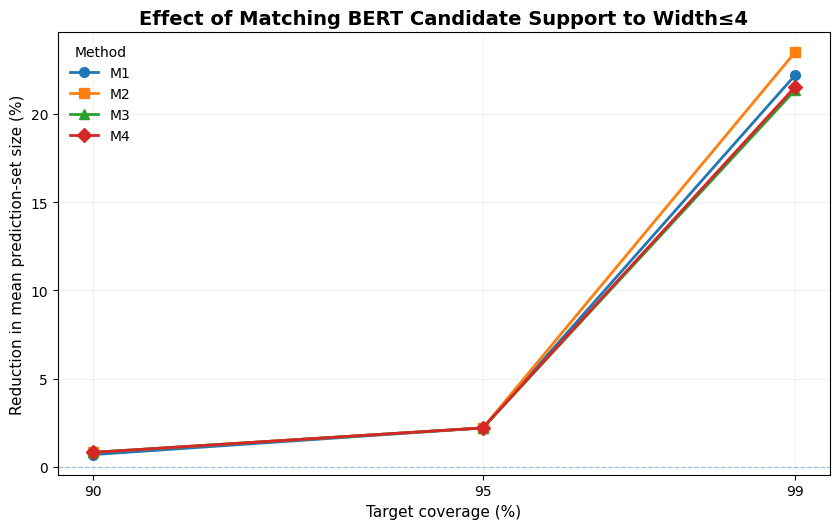

Saved figure: /kaggle/working/06_matched_width_M4_mechanism/figures/bert_width4_set_size_reduction.png


In [8]:
# Quantify how much restricting BERT to width≤4 reduces
# prediction-set size relative to its architecture-native universe.
bert_width_effect_df = (
    matched_width_operating_results_df.loc[
        matched_width_operating_results_df[
            "Model"
        ].eq("BERT")
    ]
    .copy()
)

bert_width_effect_df[
    "Set Size Reduction"
] = (
    bert_width_effect_df[
        "Native Mean Set Size"
    ]
    - bert_width_effect_df[
        "Matched Mean Set Size"
    ]
)

bert_width_effect_df[
    "Set Size Reduction (%)"
] = (
    100.0
    * bert_width_effect_df[
        "Set Size Reduction"
    ]
    / bert_width_effect_df[
        "Native Mean Set Size"
    ]
)


fig, ax = plt.subplots(
    figsize=(8.5, 5.4)
)

method_markers = {
    "M1": "o",
    "M2": "s",
    "M3": "^",
    "M4": "D",
}

for method in PRIMARY_METHODS:
    method_df = (
        bert_width_effect_df.loc[
            bert_width_effect_df[
                "Method"
            ].eq(method)
        ]
        .sort_values(
            "Target Coverage"
        )
    )

    ax.plot(
        method_df[
            "Target Coverage"
        ] * 100,
        method_df[
            "Set Size Reduction (%)"
        ],
        marker=method_markers[method],
        markersize=7,
        linewidth=2,
        label=method,
    )

# Zero represents no efficiency change after matching support.
ax.axhline(
    0,
    linestyle="--",
    linewidth=0.9,
    alpha=0.4,
)

ax.set_xticks(
    [90, 95, 99]
)

ax.set_xlabel(
    "Target coverage (%)",
    fontsize=11,
)

ax.set_ylabel(
    "Reduction in mean prediction-set size (%)",
    fontsize=11,
)

ax.set_title(
    "Effect of Matching BERT Candidate Support to Width≤4",
    fontsize=14,
    fontweight="semibold",
)

ax.legend(
    title="Method",
    frameon=False,
)

ax.grid(
    alpha=0.18,
    linewidth=0.7,
)

fig.tight_layout()


# Save the figure for dissertation reporting and downstream handoff.
OUTPUT_ROOT = Path(
    "/kaggle/working/06_matched_width_M4_mechanism"
)

FIGURE_OUTPUT_DIR = (
    OUTPUT_ROOT / "figures"
)

FIGURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

matched_width_figure_path = (
    FIGURE_OUTPUT_DIR
    / "bert_width4_set_size_reduction.png"
)

fig.savefig(
    matched_width_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved figure:",
    matched_width_figure_path,
)

The effect of matching candidate support was strongly coverage-dependent. At the 90% operating point, restricting BERT to width≤4 reduced mean prediction-set size by less than 1% for all methods. The reduction increased to approximately 2% at 95% coverage and to approximately 21–24% at 99%.

Candidate-space width therefore matters most when the conformal threshold expands far enough to admit large numbers of lower-ranked alternatives. However, because SpanNER already uses width≤4 support, this control leaves its large high-coverage M2–M4 sets unchanged. The width asymmetry is therefore not sufficient to explain the SpanNER M4 expansion.

## 4. M4 Score-Relaxation Mechanism

The matched-width control showed that candidate-space width does not explain the large SpanNER M4 prediction sets at high coverage. The next question is therefore mechanistic: **what exactly does M4 change at candidate level?**

Directly comparing the selected M3 and M4 scores is not sufficient for this purpose because the two methods do not always use the same \(\lambda\) values. For BERT, M3 and M4 both use \(\lambda_s = 0\) and \(\lambda_e = 0.01\), but for SpanNER the selected configurations differ:

* **M3:** $$ \(\lambda_s = 1.0,\ \lambda_e = 1.0\)$$
* **M4:** $$ \(\lambda_s = 1.0,\ \lambda_e = 0.3\)$$

A direct SpanNER M3–M4 difference would therefore mix two effects: changing the regularisation strength and activating uncertainty adaptation.

To isolate the uncertainty mechanism, this section constructs a **fixed- \(\lambda\) counterfactual** using M4's own frozen \(\lambda\) values but without uncertainty adaptation:

$$
a_{\mathrm{fixed}}
=
(1-c)
+
\frac{1}{2}
\left(
\lambda_s R_s + \lambda_e R_e
\right)
$$

and compares it with the actual adaptive M4 score:

$$
a_{\mathrm{M4}}
=
(1-c)
+
\frac{1}{2}
\left[
\lambda_s(1-u_s)R_s
+
\lambda_e(1-u_e)R_e
\right].
$$

The score reduction caused only by uncertainty adaptation is therefore:

$$
\Delta
=
a_{\mathrm{fixed}} - a_{\mathrm{M4}}
$$

$$
\Delta
=
\frac{1}{2}
\left(
\lambda_s u_s R_s
+
\lambda_e u_e R_e
\right).
$$

The two boundary-specific contributions are:

$$
\Delta_s
=
\frac{1}{2}\lambda_s u_s R_s
$$

$$
\Delta_e
=
\frac{1}{2}\lambda_e u_e R_e.
$$

Because \(u\) and normalized rank penalties lie between zero and one and \(\lambda\) is non-negative, M4 can only reduce or leave unchanged the corresponding fixed-\(\lambda\) candidate score. A larger \(\Delta\) therefore means that the candidate receives stronger uncertainty-driven relaxation.

This analysis returns to each architecture's **native validation candidate universe**, because the objective is to explain the primary Notebook-05 M4 behaviour rather than the width-control experiment.


### 4.1 Fixed-λ Counterfactual Decomposition

The following analysis reconstructs the fixed and adaptive scores using the frozen M4 λ values.

For BERT, the fixed-λ counterfactual is numerically identical to the selected M3 score because M3 and M4 use the same start/end λ values. For SpanNER this is deliberately **not** the case: the fixed counterfactual uses M4's `(1.0, 0.3)` λ pair rather than M3's `(1.0, 1.0)` pair.

This ensures that the measured score difference represents uncertainty adaptation alone.

In [9]:
def add_m4_relaxation_decomposition(
    df,
    model,
):
    """
    Isolate M4's uncertainty-adaptive score reduction while
    holding M4's frozen lambda values fixed.
    """
    result = df.copy().reset_index(drop=True)

    params = get_frozen_parameters(
        model,
        "M4",
    )

    lambda_start = float(
        params["lambda_start"]
    )

    lambda_end = float(
        params["lambda_end"]
    )

    base = result[
        "base_nonconformity"
    ].to_numpy(float)

    rs = result[
        "start_rank_penalty"
    ].to_numpy(float)

    re = result[
        "end_rank_penalty"
    ].to_numpy(float)

    us = result[
        "start_uncertainty"
    ].to_numpy(float)

    ue = result[
        "end_uncertainty"
    ].to_numpy(float)

    # Counterfactual fixed score using exactly M4's frozen lambdas.
    result["score_fixed_at_M4_lambda"] = (
        base
        + 0.5
        * (
            lambda_start * rs
            + lambda_end * re
        )
    )

    # Boundary-specific reductions created by uncertainty adaptation.
    result["start_relaxation"] = (
        0.5
        * lambda_start
        * us
        * rs
    )

    result["end_relaxation"] = (
        0.5
        * lambda_end
        * ue
        * re
    )

    result["total_relaxation"] = (
        result["start_relaxation"]
        + result["end_relaxation"]
    )

    # Actual adaptive M4 score.
    result["score_adaptive_M4"] = (
        base
        + 0.5
        * (
            lambda_start
            * (1.0 - us)
            * rs
            + lambda_end
            * (1.0 - ue)
            * re
        )
    )

    # Independent algebraic reconstruction:
    # adaptive score = fixed score - total relaxation.
    reconstructed_adaptive = (
        result[
            "score_fixed_at_M4_lambda"
        ]
        - result[
            "total_relaxation"
        ]
    )

    if not np.allclose(
        result["score_adaptive_M4"],
        reconstructed_adaptive,
        atol=1e-12,
        rtol=0.0,
    ):
        raise RuntimeError(
            f"M4 relaxation decomposition failed for {model}."
        )

    if (
        result["total_relaxation"]
        < -1e-12
    ).any():
        raise RuntimeError(
            f"Negative M4 relaxation detected for {model}."
        )

    return result


# Use the architecture-native Notebook-05 validation universes.
bert_mechanism_df = (
    add_m4_relaxation_decomposition(
        bert_validation_native_df,
        "BERT",
    )
)

spanner_mechanism_df = (
    add_m4_relaxation_decomposition(
        prepare_candidate_identity_types(
            spanner_validation_components_df
        ),
        "SpanNER",
    )
)


# Check whether the selected M3 and M4 lambda values are identical.
lambda_comparison_rows = []

for model in [
    "BERT",
    "SpanNER",
]:
    m3 = get_frozen_parameters(
        model,
        "M3",
    )

    m4 = get_frozen_parameters(
        model,
        "M4",
    )

    same_lambda_pair = (
        np.isclose(
            m3["lambda_start"],
            m4["lambda_start"],
        )
        and np.isclose(
            m3["lambda_end"],
            m4["lambda_end"],
        )
    )

    lambda_comparison_rows.append(
        {
            "Model": model,
            "M3 λ Start": m3["lambda_start"],
            "M3 λ End": m3["lambda_end"],
            "M4 λ Start": m4["lambda_start"],
            "M4 λ End": m4["lambda_end"],
            "Same λ Pair": same_lambda_pair,
            "Fixed Counterfactual Equals Selected M3": (
                same_lambda_pair
            ),
        }
    )


fixed_lambda_comparison_df = pd.DataFrame(
    lambda_comparison_rows
)

print(
    "Table: Fixed-λ Comparator Used to Isolate M4 Adaptation"
)
display(
    fixed_lambda_comparison_df
)

Table: Fixed-λ Comparator Used to Isolate M4 Adaptation


,Model,M3 λ Start,M3 λ End,M4 λ Start,M4 λ End,Same λ Pair,Fixed Counterfactual Equals Selected M3
0,BERT,0.0,0.01,0.0,0.01,True,True
1,SpanNER,1.0,1.00,1.0,0.30,False,False


In [10]:
def relaxation_summary(
    df,
    model,
):
    """Summarise candidate-level uncertainty-driven score relaxation."""
    total = df[
        "total_relaxation"
    ].to_numpy(float)

    start = df[
        "start_relaxation"
    ].to_numpy(float)

    end = df[
        "end_relaxation"
    ].to_numpy(float)

    positive = total[
        total > 1e-12
    ]

    return {
        "Model": model,
        "Candidates": len(df),
        "Candidates Relaxed": int(
            np.sum(total > 1e-12)
        ),
        "Candidates Relaxed (%)": (
            100.0
            * np.mean(
                total > 1e-12
            )
        ),
        "Mean Start Relaxation": float(
            start.mean()
        ),
        "Mean End Relaxation": float(
            end.mean()
        ),
        "Mean Total Relaxation": float(
            total.mean()
        ),
        "Median Positive Relaxation": (
            float(
                np.median(positive)
            )
            if len(positive)
            else 0.0
        ),
        "95th Percentile Positive Relaxation": (
            float(
                np.quantile(
                    positive,
                    0.95,
                )
            )
            if len(positive)
            else 0.0
        ),
        "Maximum Relaxation": float(
            total.max()
        ),
    }


m4_relaxation_summary_df = pd.DataFrame(
    [
        relaxation_summary(
            bert_mechanism_df,
            "BERT",
        ),
        relaxation_summary(
            spanner_mechanism_df,
            "SpanNER",
        ),
    ]
)


print(
    "Table: Candidate-Level M4 Score Relaxation"
)

display(
    m4_relaxation_summary_df.round(
        {
            "Candidates Relaxed (%)": 2,
            "Mean Start Relaxation": 6,
            "Mean End Relaxation": 6,
            "Mean Total Relaxation": 6,
            "Median Positive Relaxation": 6,
            "95th Percentile Positive Relaxation": 6,
            "Maximum Relaxation": 6,
        }
    )
)


# Structural property: adaptation cannot increase the score
# when lambda, uncertainty and rank penalties are non-negative.
mechanism_checks_df = pd.DataFrame(
    [
        {
            "Model": "BERT",
            "M4 ≤ Fixed Same-λ Score": bool(
                (
                    bert_mechanism_df[
                        "score_adaptive_M4"
                    ]
                    <= bert_mechanism_df[
                        "score_fixed_at_M4_lambda"
                    ]
                    + 1e-12
                ).all()
            ),
            "Relaxation Decomposition Exact": bool(
                np.allclose(
                    bert_mechanism_df[
                        "score_fixed_at_M4_lambda"
                    ]
                    - bert_mechanism_df[
                        "score_adaptive_M4"
                    ],
                    bert_mechanism_df[
                        "total_relaxation"
                    ],
                    atol=1e-12,
                )
            ),
        },
        {
            "Model": "SpanNER",
            "M4 ≤ Fixed Same-λ Score": bool(
                (
                    spanner_mechanism_df[
                        "score_adaptive_M4"
                    ]
                    <= spanner_mechanism_df[
                        "score_fixed_at_M4_lambda"
                    ]
                    + 1e-12
                ).all()
            ),
            "Relaxation Decomposition Exact": bool(
                np.allclose(
                    spanner_mechanism_df[
                        "score_fixed_at_M4_lambda"
                    ]
                    - spanner_mechanism_df[
                        "score_adaptive_M4"
                    ],
                    spanner_mechanism_df[
                        "total_relaxation"
                    ],
                    atol=1e-12,
                )
            ),
        },
    ]
)

print(
    "\nTable: M4 Mechanism Integrity Checks"
)

display(
    mechanism_checks_df
)

print(
    "\nMechanism population:",
    "architecture-native validation candidates",
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Conformal thresholds changed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Candidate-Level M4 Score Relaxation


,Model,Candidates,Candidates Relaxed,Candidates Relaxed (%),Mean Start Relaxation,Mean End Relaxation,Mean Total Relaxation,Median Positive Relaxation,95th Percentile Positive Relaxation,Maximum Relaxation
0,BERT,1399604,1210725,86.5,0.000000,0.000030,0.000030,0.000000,0.000005,0.004971
1,SpanNER,377988,339066,89.7,0.192569,0.057094,0.249663,0.263851,0.570036,0.649999



Table: M4 Mechanism Integrity Checks


,Model,M4 ≤ Fixed Same-λ Score,Relaxation Decomposition Exact
0,BERT,True,True
1,SpanNER,True,True



Mechanism population: architecture-native validation candidates
Lambda retuning performed: False
Conformal thresholds changed: False
Official CoNLL test accessed: False


## 5. Gold vs Non-Gold Candidate Effects

The preceding decomposition showed a large architecture difference in the magnitude of uncertainty-driven relaxation. BERT's adaptive effect was numerically very small, whereas SpanNER candidates received substantially larger score reductions.

A useful uncertainty mechanism should preferentially preserve plausible alternatives around difficult entities. However, the conformal candidate universe contains far more non-gold than gold typed spans. Large adaptive reductions applied to weak non-gold candidates could therefore increase prediction-set size without providing a corresponding coverage benefit.

This section separates representable gold candidates from all other typed candidates and examines four quantities:

- candidate confidence `c`;
- start and end uncertainty `uₛ` and `uₑ`;
- total M4 score relaxation `Δ`;
- the proportion of the total relaxation mass assigned to gold versus non-gold candidates.

The analysis is descriptive and uses the frozen architecture-native validation candidate populations. It does not alter λ values or conformal thresholds.

### 5.1 Which Candidates Receive M4 Relaxation?

Gold candidates are the typed spans that exactly correspond to representable gold entities. Every other typed candidate is treated as non-gold for this mechanism analysis.

Because the candidate universe is highly imbalanced, raw counts alone are not sufficient. The comparison therefore reports both candidate-level averages and each group's share of the total uncertainty-driven score reduction.

If M4's adaptive relaxation is concentrated on very low-confidence non-gold candidates, this would provide a direct mechanism by which large prediction sets can emerge at permissive conformal thresholds.

In [11]:
def summarise_gold_non_gold_relaxation(
    df,
    model,
):
    """Compare M4 mechanism quantities for gold and non-gold candidates."""
    rows = []

    total_relaxation_mass = float(
        df["total_relaxation"].sum()
    )

    for is_gold, group_name in [
        (True, "Gold"),
        (False, "Non-gold"),
    ]:
        group_df = df.loc[
            df["is_gold_candidate"].eq(is_gold)
        ]

        relaxation = group_df[
            "total_relaxation"
        ].to_numpy(float)

        rows.append(
            {
                "Model": model,
                "Candidate Group": group_name,
                "Candidates": len(group_df),
                "Candidate Share (%)": (
                    100.0
                    * len(group_df)
                    / len(df)
                ),
                "Mean Confidence": float(
                    group_df[
                        "base_confidence"
                    ].mean()
                ),
                "Median Confidence": float(
                    group_df[
                        "base_confidence"
                    ].median()
                ),
                "Mean Start Uncertainty": float(
                    group_df[
                        "start_uncertainty"
                    ].mean()
                ),
                "Mean End Uncertainty": float(
                    group_df[
                        "end_uncertainty"
                    ].mean()
                ),
                "Mean Start Rank Penalty": float(
                    group_df[
                        "start_rank_penalty"
                    ].mean()
                ),
                "Mean End Rank Penalty": float(
                    group_df[
                        "end_rank_penalty"
                    ].mean()
                ),
                "Candidates Relaxed (%)": (
                    100.0
                    * np.mean(
                        relaxation > 1e-12
                    )
                ),
                "Mean Total Relaxation": float(
                    relaxation.mean()
                ),
                "Median Total Relaxation": float(
                    np.median(relaxation)
                ),
                "95th Percentile Relaxation": float(
                    np.quantile(
                        relaxation,
                        0.95,
                    )
                ),
                "Relaxation Mass Share (%)": (
                    (
                        100.0
                        * relaxation.sum()
                        / total_relaxation_mass
                    )
                    if total_relaxation_mass > 0
                    else 0.0
                ),
            }
        )

    return rows


gold_non_gold_relaxation_df = pd.DataFrame(
    summarise_gold_non_gold_relaxation(
        bert_mechanism_df,
        "BERT",
    )
    + summarise_gold_non_gold_relaxation(
        spanner_mechanism_df,
        "SpanNER",
    )
)


print(
    "Table: Gold vs Non-Gold M4 Relaxation"
)

display(
    gold_non_gold_relaxation_df.round(
        {
            "Candidate Share (%)": 3,
            "Mean Confidence": 6,
            "Median Confidence": 6,
            "Mean Start Uncertainty": 6,
            "Mean End Uncertainty": 6,
            "Mean Start Rank Penalty": 6,
            "Mean End Rank Penalty": 6,
            "Candidates Relaxed (%)": 2,
            "Mean Total Relaxation": 6,
            "Median Total Relaxation": 6,
            "95th Percentile Relaxation": 6,
            "Relaxation Mass Share (%)": 3,
        }
    )
)

Table: Gold vs Non-Gold M4 Relaxation


,Model,Candidate Group,Candidates,Candidate Share (%),Mean Confidence,Median Confidence,Mean Start Uncertainty,Mean End Uncertainty,Mean Start Rank Penalty,Mean End Rank Penalty,Candidates Relaxed (%),Mean Total Relaxation,Median Total Relaxation,95th Percentile Relaxation,Relaxation Mass Share (%)
0,BERT,Gold,3011,0.215,0.935280,0.990363,0.009023,0.002669,0.003134,0.056693,28.86,0.000001,0.000000,0.000000,0.004
1,BERT,Non-gold,1396593,99.785,0.001609,0.000144,0.460147,0.011982,0.498744,0.498629,86.63,0.000030,0.000000,0.000004,99.996
2,SpanNER,Gold,2993,0.792,0.931859,0.986586,0.033440,0.030332,0.005067,0.003508,1.64,0.002501,0.000000,0.000000,0.008
3,SpanNER,Non-gold,374995,99.208,0.000867,0.000000,0.632389,0.630855,0.495283,0.495296,90.41,0.251636,0.234631,0.559637,99.992


In [12]:
mechanism_core_columns = [
    "Model",
    "Candidate Group",
    "Candidates",
    "Mean Confidence",
    "Mean Start Uncertainty",
    "Mean End Uncertainty",
    "Mean Total Relaxation",
    "95th Percentile Relaxation",
    "Relaxation Mass Share (%)",
]

gold_non_gold_core_df = (
    gold_non_gold_relaxation_df[
        mechanism_core_columns
    ]
    .copy()
)


print(
    "Table: Core Gold vs Non-Gold Mechanism Comparison"
)

display(
    gold_non_gold_core_df.round(
        {
            "Mean Confidence": 6,
            "Mean Start Uncertainty": 6,
            "Mean End Uncertainty": 6,
            "Mean Total Relaxation": 6,
            "95th Percentile Relaxation": 6,
            "Relaxation Mass Share (%)": 2,
        }
    )
)


# Gold candidates should remain a small subset of the complete
# typed candidate universe for both architectures.
candidate_counts_check_df = pd.DataFrame(
    [
        {
            "Model": "BERT",
            "Gold Candidates": int(
                bert_mechanism_df[
                    "is_gold_candidate"
                ].sum()
            ),
            "Non-Gold Candidates": int(
                (~bert_mechanism_df[
                    "is_gold_candidate"
                ]).sum()
            ),
        },
        {
            "Model": "SpanNER",
            "Gold Candidates": int(
                spanner_mechanism_df[
                    "is_gold_candidate"
                ].sum()
            ),
            "Non-Gold Candidates": int(
                (~spanner_mechanism_df[
                    "is_gold_candidate"
                ]).sum()
            ),
        },
    ]
)

print(
    "\nTable: Mechanism Candidate Population"
)

display(
    candidate_counts_check_df
)

print(
    "\nMechanism population:",
    "architecture-native validation candidates",
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Core Gold vs Non-Gold Mechanism Comparison


,Model,Candidate Group,Candidates,Mean Confidence,Mean Start Uncertainty,Mean End Uncertainty,Mean Total Relaxation,95th Percentile Relaxation,Relaxation Mass Share (%)
0,BERT,Gold,3011,0.935280,0.009023,0.002669,0.000001,0.000000,0.00
1,BERT,Non-gold,1396593,0.001609,0.460147,0.011982,0.000030,0.000004,100.00
2,SpanNER,Gold,2993,0.931859,0.033440,0.030332,0.002501,0.000000,0.01
3,SpanNER,Non-gold,374995,0.000867,0.632389,0.630855,0.251636,0.559637,99.99



Table: Mechanism Candidate Population


,Model,Gold Candidates,Non-Gold Candidates
0,BERT,3011,1396593
1,SpanNER,2993,374995



Mechanism population: architecture-native validation candidates
Lambda retuning performed: False
Official CoNLL test accessed: False


### 5.2 Relaxation Is Concentrated on Weak Non-Gold Candidates

The gold/non-gold decomposition reveals a pronounced asymmetry in how M4's adaptive relaxation is distributed.

For BERT, representable gold candidates had a mean confidence of 0.9353 and received essentially no adaptive score reduction: mean total relaxation was approximately 0.000001. Non-gold candidates had much lower confidence, 0.0016 on average, and accounted for virtually all of BERT's relaxation mass. However, their mean relaxation remained extremely small at approximately 0.00003, so the practical effect of this behaviour is limited.

The same pattern was substantially stronger for SpanNER. Gold candidates had mean confidence 0.9319 and low boundary competition, with mean start and end uncertainty of 0.0334 and 0.0303. Their mean total relaxation was only 0.0025. In contrast, non-gold candidates had mean confidence of only 0.000867 but mean start and end uncertainty of 0.6324 and 0.6309. Their mean adaptive score reduction was 0.2516, approximately two orders of magnitude larger than that of gold candidates.

Consequently, 99.99% of SpanNER's aggregate adaptive relaxation was assigned to non-gold candidates. This is not merely a consequence of class imbalance: the per-candidate relaxation was itself substantially larger for the non-gold population.

These results identify a plausible mechanism for M4's high-coverage inefficiency. The SpanNER competition signal can be large for a weak candidate when a much stronger neighbouring span exists. M4 interprets this high competition value as a reason to relax the candidate's boundary-rank penalty, even when the candidate's own confidence is extremely small. At permissive conformal thresholds, sufficiently strong relaxation of many such candidates can enlarge the prediction set without materially improving gold coverage.

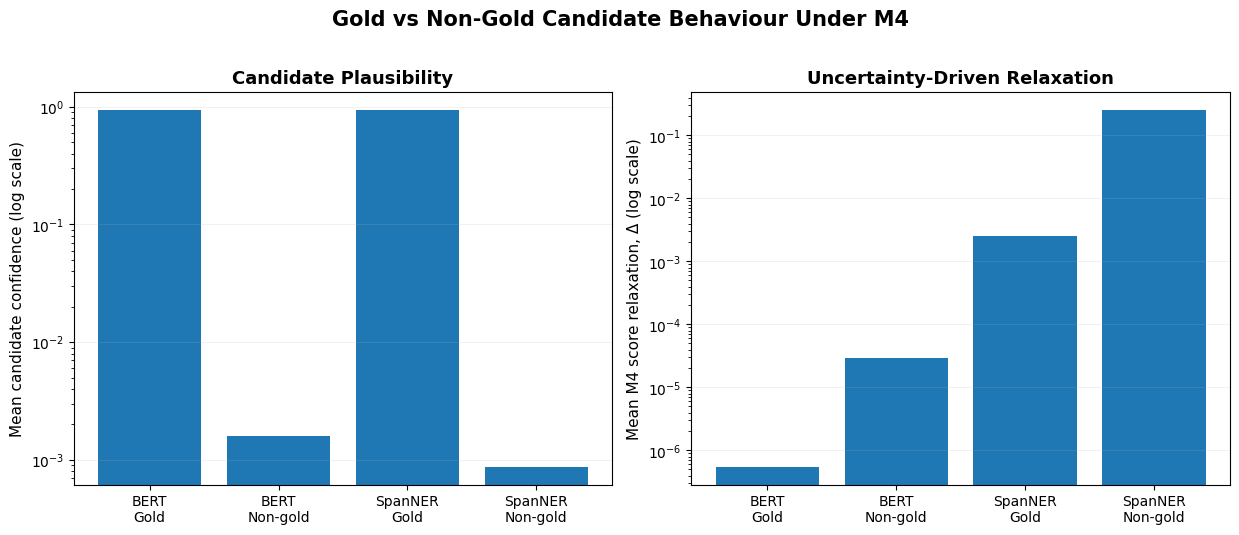

Saved figure: /kaggle/working/06_matched_width_M4_mechanism/figures/gold_non_gold_M4_mechanism.png


In [13]:
# Visualise the two quantities that explain the SpanNER mechanism:
# candidate plausibility and uncertainty-driven score relaxation.
figure_data = (
    gold_non_gold_core_df
    .copy()
)

figure_data["Label"] = (
    figure_data["Model"]
    + "\n"
    + figure_data["Candidate Group"]
)

x_positions = np.arange(
    len(figure_data)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.2),
)


# Panel A: candidate confidence.
axes[0].bar(
    x_positions,
    figure_data["Mean Confidence"],
)

axes[0].set_xticks(
    x_positions
)

axes[0].set_xticklabels(
    figure_data["Label"],
)

axes[0].set_yscale(
    "log"
)

axes[0].set_ylabel(
    "Mean candidate confidence (log scale)",
    fontsize=11,
)

axes[0].set_title(
    "Candidate Plausibility",
    fontsize=13,
    fontweight="semibold",
)

axes[0].grid(
    axis="y",
    alpha=0.18,
    linewidth=0.7,
)


# Panel B: uncertainty-driven M4 score reduction.
axes[1].bar(
    x_positions,
    figure_data["Mean Total Relaxation"],
)

axes[1].set_xticks(
    x_positions
)

axes[1].set_xticklabels(
    figure_data["Label"],
)

axes[1].set_yscale(
    "log"
)

axes[1].set_ylabel(
    "Mean M4 score relaxation, Δ (log scale)",
    fontsize=11,
)

axes[1].set_title(
    "Uncertainty-Driven Relaxation",
    fontsize=13,
    fontweight="semibold",
)

axes[1].grid(
    axis="y",
    alpha=0.18,
    linewidth=0.7,
)


fig.suptitle(
    "Gold vs Non-Gold Candidate Behaviour Under M4",
    fontsize=15,
    fontweight="semibold",
    y=1.02,
)

fig.tight_layout()


gold_non_gold_figure_path = (
    FIGURE_OUTPUT_DIR
    / "gold_non_gold_M4_mechanism.png"
)

fig.savefig(
    gold_non_gold_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved figure:",
    gold_non_gold_figure_path,
)

### 5.3 Common-Threshold Fixed-to-Adaptive Diagnostic

The preceding analysis establishes where M4 reduces candidate scores, but method-specific conformal thresholds can partly offset or amplify those reductions. To isolate the effect of the adaptive score transformation itself, a second counterfactual holds the threshold fixed.

Within each of the five duplicate-safe validation folds, the other four folds form a 1,300-sentence pseudo-calibration population. A conformal threshold is estimated from the **fixed score using M4's own frozen λ values**. That exact same threshold is then applied to both:

- the fixed same-λ score; and
- the uncertainty-adaptive M4 score

on the held-out 325 sentences.

Because the threshold and λ values are identical, any candidate that enters the adaptive set but not the fixed set does so **solely because of uncertainty-driven score relaxation**.

This is a mechanism diagnostic rather than an alternative conformal evaluation. The adaptive score is deliberately not recalibrated to obtain its own threshold in this comparison.

In [14]:
# Resolve the existing duplicate-safe validation fold column.
possible_fold_columns = [
    column
    for column in validation_fold_df.columns
    if column.lower() in {
        "fold",
        "fold_id",
        "validation_fold",
    }
]

if len(possible_fold_columns) != 1:
    raise RuntimeError(
        "Could not uniquely identify the validation fold column. "
        f"Available columns: {list(validation_fold_df.columns)}"
    )

FOLD_COLUMN = possible_fold_columns[0]


fold_lookup_df = (
    validation_fold_df[
        [
            "sentence_id",
            FOLD_COLUMN,
        ]
    ]
    .copy()
)

fold_lookup_df["sentence_id"] = (
    fold_lookup_df[
        "sentence_id"
    ].astype(int)
)

fold_lookup_df[FOLD_COLUMN] = (
    fold_lookup_df[
        FOLD_COLUMN
    ].astype(int)
)

if fold_lookup_df[
    "sentence_id"
].duplicated().any():
    raise RuntimeError(
        "Validation fold assignment contains duplicate sentence IDs."
    )


def attach_validation_fold(
    candidate_df,
):
    """Attach the frozen duplicate-safe fold to each candidate."""
    result = candidate_df.merge(
        fold_lookup_df,
        on="sentence_id",
        how="left",
        validate="many_to_one",
    )

    if result[
        FOLD_COLUMN
    ].isna().any():
        raise RuntimeError(
            "Some candidate sentences are missing a validation fold."
        )

    result[FOLD_COLUMN] = (
        result[
            FOLD_COLUMN
        ].astype(int)
    )

    return result


bert_common_q_df = attach_validation_fold(
    bert_mechanism_df
)

spanner_common_q_df = attach_validation_fold(
    spanner_mechanism_df
)


def evaluate_common_threshold_adaptation(
    df,
    model,
):
    """
    Compare fixed and adaptive scores using exactly the same
    fold-specific threshold. This isolates score relaxation.
    """
    fold_rows = []

    unique_folds = sorted(
        df[FOLD_COLUMN].unique()
    )

    if unique_folds != [0, 1, 2, 3, 4]:
        raise RuntimeError(
            f"Unexpected validation folds for {model}: {unique_folds}"
        )

    for held_out_fold in unique_folds:

        pseudo_calibration_df = df.loc[
            df[FOLD_COLUMN] != held_out_fold
        ]

        held_out_df = df.loc[
            df[FOLD_COLUMN] == held_out_fold
        ].copy()

        pseudo_calibration_sentences = (
            pseudo_calibration_df[
                "sentence_id"
            ].nunique()
        )

        held_out_sentences = (
            held_out_df[
                "sentence_id"
            ].nunique()
        )

        if pseudo_calibration_sentences != 1300:
            raise RuntimeError(
                f"{model} fold {held_out_fold}: "
                "expected 1,300 pseudo-calibration sentences."
            )

        if held_out_sentences != 325:
            raise RuntimeError(
                f"{model} fold {held_out_fold}: "
                "expected 325 held-out sentences."
            )

        # Sentence-level gold conformity for the fixed same-lambda score.
        pseudo_calibration_scores = (
            sentence_gold_max_scores(
                pseudo_calibration_df,
                "score_fixed_at_M4_lambda",
            )
        )

        for target in TARGET_COVERAGES:

            q_fixed, order_rank = (
                finite_sample_quantile(
                    pseudo_calibration_scores.to_numpy(),
                    target,
                )
            )

            # The same q is deliberately applied to both scores.
            fixed_included = (
                held_out_df[
                    "score_fixed_at_M4_lambda"
                ]
                <= q_fixed
            )

            adaptive_included = (
                held_out_df[
                    "score_adaptive_M4"
                ]
                <= q_fixed
            )

            added = (
                adaptive_included
                & ~fixed_included
            )

            removed = (
                fixed_included
                & ~adaptive_included
            )

            # M4 can only lower the same-lambda score, so the adaptive
            # set must contain the fixed set at a common threshold.
            if removed.any():
                raise RuntimeError(
                    f"{model} fold {held_out_fold}: "
                    "adaptive M4 removed candidates at common q."
                )

            sentence_ids = np.sort(
                held_out_df[
                    "sentence_id"
                ].unique()
            )

            fixed_set_size = (
                held_out_df.loc[
                    fixed_included
                ]
                .groupby(
                    "sentence_id"
                )
                .size()
                .reindex(
                    sentence_ids,
                    fill_value=0,
                )
            )

            adaptive_set_size = (
                held_out_df.loc[
                    adaptive_included
                ]
                .groupby(
                    "sentence_id"
                )
                .size()
                .reindex(
                    sentence_ids,
                    fill_value=0,
                )
            )

            # Gold coverage under the identical threshold.
            fixed_gold_scores = (
                sentence_gold_max_scores(
                    held_out_df,
                    "score_fixed_at_M4_lambda",
                )
            )

            adaptive_gold_scores = (
                sentence_gold_max_scores(
                    held_out_df,
                    "score_adaptive_M4",
                )
            )

            added_df = held_out_df.loc[
                added
            ]

            fold_rows.append(
                {
                    "Model": model,
                    "Held-out Fold": held_out_fold,
                    "Target Coverage": target,
                    "Order Rank": order_rank,
                    "Common q_hat": q_fixed,
                    "Fixed Mean Set Size": float(
                        fixed_set_size.mean()
                    ),
                    "Adaptive Mean Set Size": float(
                        adaptive_set_size.mean()
                    ),
                    "Set Size Increase": float(
                        adaptive_set_size.mean()
                        - fixed_set_size.mean()
                    ),
                    "Fixed Gold Coverage": float(
                        (
                            fixed_gold_scores
                            <= q_fixed
                        ).mean()
                    ),
                    "Adaptive Gold Coverage": float(
                        (
                            adaptive_gold_scores
                            <= q_fixed
                        ).mean()
                    ),
                    "Added Candidates": int(
                        added.sum()
                    ),
                    "Added Gold Candidates": int(
                        (
                            added
                            & held_out_df[
                                "is_gold_candidate"
                            ]
                        ).sum()
                    ),
                    "Added Non-Gold Candidates": int(
                        (
                            added
                            & ~held_out_df[
                                "is_gold_candidate"
                            ]
                        ).sum()
                    ),
                    "Added Confidence Sum": float(
                        added_df[
                            "base_confidence"
                        ].sum()
                    ),
                    "Added Relaxation Sum": float(
                        added_df[
                            "total_relaxation"
                        ].sum()
                    ),
                }
            )

    return pd.DataFrame(
        fold_rows
    )


bert_common_threshold_fold_df = (
    evaluate_common_threshold_adaptation(
        bert_common_q_df,
        "BERT",
    )
)

spanner_common_threshold_fold_df = (
    evaluate_common_threshold_adaptation(
        spanner_common_q_df,
        "SpanNER",
    )
)

common_threshold_fold_df = pd.concat(
    [
        bert_common_threshold_fold_df,
        spanner_common_threshold_fold_df,
    ],
    ignore_index=True,
)

### Aggregate the five held-out folds

In [15]:
common_threshold_rows = []

for (
    model,
    target,
), group_df in common_threshold_fold_df.groupby(
    [
        "Model",
        "Target Coverage",
    ],
    sort=False,
):

    added_candidates = int(
        group_df[
            "Added Candidates"
        ].sum()
    )

    added_gold = int(
        group_df[
            "Added Gold Candidates"
        ].sum()
    )

    added_non_gold = int(
        group_df[
            "Added Non-Gold Candidates"
        ].sum()
    )

    common_threshold_rows.append(
        {
            "Model": model,
            "Target Coverage": target,
            "Fixed Mean Set Size": float(
                group_df[
                    "Fixed Mean Set Size"
                ].mean()
            ),
            "Adaptive Same-q Mean Set Size": float(
                group_df[
                    "Adaptive Mean Set Size"
                ].mean()
            ),
            "Mean Set Size Increase": float(
                group_df[
                    "Set Size Increase"
                ].mean()
            ),
            "Fixed Gold Coverage": float(
                group_df[
                    "Fixed Gold Coverage"
                ].mean()
            ),
            "Adaptive Same-q Gold Coverage": float(
                group_df[
                    "Adaptive Gold Coverage"
                ].mean()
            ),
            "Coverage Gain": float(
                (
                    group_df[
                        "Adaptive Gold Coverage"
                    ]
                    - group_df[
                        "Fixed Gold Coverage"
                    ]
                ).mean()
            ),
            "Added Candidates": added_candidates,
            "Added Gold": added_gold,
            "Added Non-Gold": added_non_gold,
            "Added Candidates Gold (%)": (
                100.0
                * added_gold
                / added_candidates
                if added_candidates > 0
                else 0.0
            ),
            "Mean Confidence of Added": (
                float(
                    group_df[
                        "Added Confidence Sum"
                    ].sum()
                    / added_candidates
                )
                if added_candidates > 0
                else np.nan
            ),
            "Mean Relaxation of Added": (
                float(
                    group_df[
                        "Added Relaxation Sum"
                    ].sum()
                    / added_candidates
                )
                if added_candidates > 0
                else np.nan
            ),
        }
    )


common_threshold_summary_df = pd.DataFrame(
    common_threshold_rows
)


print(
    "Table: Common-Threshold Fixed-to-Adaptive M4 Diagnostic"
)

display(
    common_threshold_summary_df.round(
        {
            "Target Coverage": 2,
            "Fixed Mean Set Size": 4,
            "Adaptive Same-q Mean Set Size": 4,
            "Mean Set Size Increase": 4,
            "Fixed Gold Coverage": 6,
            "Adaptive Same-q Gold Coverage": 6,
            "Coverage Gain": 6,
            "Added Candidates Gold (%)": 4,
            "Mean Confidence of Added": 6,
            "Mean Relaxation of Added": 6,
        }
    )
)


expected_pseudo_calibration_ranks = {
    0.90: 1171,
    0.95: 1236,
    0.99: 1288,
}

observed_ranks = (
    common_threshold_fold_df[
        [
            "Target Coverage",
            "Order Rank",
        ]
    ]
    .drop_duplicates()
    .set_index(
        "Target Coverage"
    )["Order Rank"]
    .to_dict()
)

if observed_ranks != expected_pseudo_calibration_ranks:
    raise RuntimeError(
        "Unexpected cross-fitted pseudo-calibration order ranks."
    )


print(
    "\nPseudo-calibration order ranks:",
    observed_ranks,
)

print(
    "Same threshold applied to fixed and adaptive scores:",
    True,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Common-Threshold Fixed-to-Adaptive M4 Diagnostic


,Model,Target Coverage,Fixed Mean Set Size,Adaptive Same-q Mean Set Size,Mean Set Size Increase,Fixed Gold Coverage,Adaptive Same-q Gold Coverage,Coverage Gain,Added Candidates,Added Gold,Added Non-Gold,Added Candidates Gold (%),Mean Confidence of Added,Mean Relaxation of Added
0,BERT,0.90,2.6006,2.6006,0.0000,0.900923,0.900923,0.000000,0,0,0,0.0000,NaN,NaN
1,BERT,0.95,2.8960,2.8960,0.0000,0.948923,0.948923,0.000000,0,0,0,0.0000,NaN,NaN
2,BERT,0.99,10.7397,10.8769,0.1372,0.990154,0.990154,0.000000,223,0,223,0.0000,0.007329,0.002778
3,SpanNER,0.90,1.7532,1.7545,0.0012,0.899692,0.899692,0.000000,2,0,2,0.0000,0.957308,0.097062
4,SpanNER,0.95,1.9514,1.9778,0.0265,0.948308,0.948923,0.000615,43,1,42,2.3256,0.356927,0.149634
5,SpanNER,0.99,60.3360,185.2486,124.9126,0.989538,1.000000,0.010462,202983,18,202965,0.0089,0.000138,0.305980



Pseudo-calibration order ranks: {0.9: 1171, 0.95: 1236, 0.99: 1288}
Same threshold applied to fixed and adaptive scores: True
Lambda retuning performed: False
Official CoNLL test accessed: False


### 5.4 Effect of Adaptive Relaxation at a Common Threshold

Holding λ and the conformal threshold fixed isolates the direct effect of uncertainty adaptation on prediction-set membership.

For BERT, the adaptive transformation had essentially no effect at the 90% and 95% operating points. At 99%, it admitted 223 additional candidates across the validation population, all of which were non-gold. Mean set size increased only from 10.74 to 10.88 and representable-gold coverage did not change.

SpanNER showed a markedly different pattern. At 90%, only two additional non-gold candidates entered the adaptive sets. At 95%, adaptation admitted 43 candidates, of which one was gold, increasing mean set size by 0.027 and representable-gold coverage by 0.0006.

The mechanism became extreme at the 99% operating point. Using exactly the same threshold, the fixed same-λ score produced a mean set size of 60.34 candidates per sentence, whereas uncertainty adaptation increased this to 185.25. Across the five held-out folds, 202,983 additional candidates crossed the threshold. Only 18 of these were gold; approximately 99.99% were non-gold. The added candidates had mean confidence of only 0.000138 but received a mean adaptive score reduction of 0.306.

The resulting representable-gold coverage increased from 0.9895 to 1.0000, but this approximately one-percentage-point gain required an increase of 124.91 candidates per sentence. The diagnostic therefore identifies a concrete mechanism for the high-coverage SpanNER expansion: once the conformal threshold becomes permissive, uncertainty adaptation can move very large numbers of extremely low-confidence alternatives below the inclusion threshold.

This common-threshold experiment is a mechanism counterfactual rather than an alternative calibrated conformal result. Its purpose is specifically to isolate the effect of adaptive score relaxation from the separate effect of method-specific conformal recalibration.

## 6. SpanNER Competition Semantics

The preceding analysis showed that large M4 relaxations are concentrated on extremely low-confidence SpanNER candidates. This section examines why those candidates nevertheless receive large boundary-uncertainty values.

For SpanNER, the boundary signal compares the current candidate probability `c` with the strongest same-type local boundary competitor:

$$u = p_comp / (c + p_comp + ε)$$

The value therefore describes the **relative strength of the competing candidate**, not the absolute plausibility of the current candidate.

Ignoring the negligible numerical stabiliser:

- `u < 0.5` implies `c > p_comp`: the current candidate is stronger;
- `u = 0.5` implies `c = p_comp`;
- `u > 0.5` implies `p_comp > c`: the competitor is stronger.

More generally,

$$p_comp / c ≈ u / (1 − u)$$

Thus, `u ≥ 0.909` corresponds approximately to a competitor that is at least ten times more probable than the current candidate.

This distinction matters for M4. A high `u` reduces the boundary-rank penalty regardless of whether it arises from a genuine near-tie between two plausible alternatives or from a very weak candidate being dominated by a much stronger neighbour.

The following analysis separates these competition states for representable gold and non-gold candidates.

In [16]:
# Reconstruct local group sizes from the complete native SpanNER universe.
# A group size of one means that no alternative boundary candidate exists.
spanner_competition_df = (
    spanner_mechanism_df
    .copy()
)

spanner_competition_df["start_group_size"] = (
    spanner_competition_df
    .groupby(
        [
            "sentence_id",
            "end",
            "entity_type",
        ],
        sort=False,
    )["base_confidence"]
    .transform("size")
    .astype(int)
)

spanner_competition_df["end_group_size"] = (
    spanner_competition_df
    .groupby(
        [
            "sentence_id",
            "start",
            "entity_type",
        ],
        sort=False,
    )["base_confidence"]
    .transform("size")
    .astype(int)
)


def classify_competition_state(
    uncertainty,
    group_size,
):
    """
    Interpret SpanNER u through its probability-ratio definition.

    u < 0.5  -> candidate stronger
    u = 0.5  -> equal strength
    u > 0.5  -> competitor stronger
    """
    uncertainty = np.asarray(
        uncertainty,
        dtype=float,
    )

    group_size = np.asarray(
        group_size,
        dtype=int,
    )

    states = np.full(
        len(uncertainty),
        "No competitor",
        dtype=object,
    )

    has_competitor = (
        group_size > 1
    )

    states[
        has_competitor
        & (uncertainty < 0.5 - 1e-12)
    ] = "Candidate stronger"

    states[
        has_competitor
        & np.isclose(
            uncertainty,
            0.5,
            atol=1e-12,
            rtol=0.0,
        )
    ] = "Equal strength"

    states[
        has_competitor
        & (uncertainty > 0.5 + 1e-12)
    ] = "Competitor stronger"

    return states


spanner_competition_df[
    "start_competition_state"
] = classify_competition_state(
    spanner_competition_df[
        "start_uncertainty"
    ],
    spanner_competition_df[
        "start_group_size"
    ],
)

spanner_competition_df[
    "end_competition_state"
] = classify_competition_state(
    spanner_competition_df[
        "end_uncertainty"
    ],
    spanner_competition_df[
        "end_group_size"
    ],
)


# u >= 10/11 means the strongest competitor is approximately
# at least ten times stronger than the current candidate.
TENFOLD_DOMINANCE_THRESHOLD = (
    10.0 / 11.0
)

spanner_competition_df[
    "start_competitor_at_least_10x"
] = (
    (
        spanner_competition_df[
            "start_group_size"
        ] > 1
    )
    & (
        spanner_competition_df[
            "start_uncertainty"
        ]
        >= TENFOLD_DOMINANCE_THRESHOLD
    )
)

spanner_competition_df[
    "end_competitor_at_least_10x"
] = (
    (
        spanner_competition_df[
            "end_group_size"
        ] > 1
    )
    & (
        spanner_competition_df[
            "end_uncertainty"
        ]
        >= TENFOLD_DOMINANCE_THRESHOLD
    )
)


print(
    "10× competitor-dominance threshold in u:",
    round(
        TENFOLD_DOMINANCE_THRESHOLD,
        6,
    ),
)

print(
    "Start singleton groups:",
    int(
        (
            spanner_competition_df[
                "start_group_size"
            ] == 1
        ).sum()
    ),
)

print(
    "End singleton groups:",
    int(
        (
            spanner_competition_df[
                "end_group_size"
            ] == 1
        ).sum()
    ),
)

10× competitor-dominance threshold in u: 0.909091
Start singleton groups: 6500
End singleton groups: 6500


### Gold vs non-gold competition states

In [17]:
def competition_semantics_summary(
    df,
    boundary,
):
    """Summarise competition direction for gold and non-gold candidates."""
    uncertainty_column = (
        f"{boundary}_uncertainty"
    )

    group_size_column = (
        f"{boundary}_group_size"
    )

    state_column = (
        f"{boundary}_competition_state"
    )

    dominance_column = (
        f"{boundary}_competitor_at_least_10x"
    )

    rows = []

    for is_gold, group_name in [
        (True, "Gold"),
        (False, "Non-gold"),
    ]:
        group_df = df.loc[
            df["is_gold_candidate"].eq(is_gold)
        ]

        with_competitor = group_df.loc[
            group_df[
                group_size_column
            ] > 1
        ]

        n_with_competitor = len(
            with_competitor
        )

        rows.append(
            {
                "Boundary": boundary.capitalize(),
                "Candidate Group": group_name,
                "Candidates": len(group_df),
                "Competitor Available (%)": (
                    100.0
                    * n_with_competitor
                    / len(group_df)
                ),
                "Mean Confidence": float(
                    group_df[
                        "base_confidence"
                    ].mean()
                ),
                "Mean u": float(
                    group_df[
                        uncertainty_column
                    ].mean()
                ),
                "Candidate Stronger (%)": (
                    100.0
                    * (
                        with_competitor[
                            state_column
                        ]
                        == "Candidate stronger"
                    ).mean()
                    if n_with_competitor
                    else 0.0
                ),
                "Equal Strength (%)": (
                    100.0
                    * (
                        with_competitor[
                            state_column
                        ]
                        == "Equal strength"
                    ).mean()
                    if n_with_competitor
                    else 0.0
                ),
                "Competitor Stronger (%)": (
                    100.0
                    * (
                        with_competitor[
                            state_column
                        ]
                        == "Competitor stronger"
                    ).mean()
                    if n_with_competitor
                    else 0.0
                ),
                "Competitor ≥10× Stronger (%)": (
                    100.0
                    * with_competitor[
                        dominance_column
                    ].mean()
                    if n_with_competitor
                    else 0.0
                ),
            }
        )

    return rows


span_competition_semantics_df = pd.DataFrame(
    competition_semantics_summary(
        spanner_competition_df,
        "start",
    )
    + competition_semantics_summary(
        spanner_competition_df,
        "end",
    )
)


print(
    "Table: SpanNER Boundary-Competition Semantics"
)

display(
    span_competition_semantics_df.round(
        {
            "Competitor Available (%)": 2,
            "Mean Confidence": 6,
            "Mean u": 6,
            "Candidate Stronger (%)": 2,
            "Equal Strength (%)": 4,
            "Competitor Stronger (%)": 2,
            "Competitor ≥10× Stronger (%)": 2,
        }
    )
)


# Confirm that the three mutually exclusive competition states
# account for every candidate for which an alternative exists.
for boundary in [
    "start",
    "end",
]:

    available = (
        spanner_competition_df[
            f"{boundary}_group_size"
        ] > 1
    )

    valid_states = {
        "Candidate stronger",
        "Equal strength",
        "Competitor stronger",
    }

    observed_states = set(
        spanner_competition_df.loc[
            available,
            f"{boundary}_competition_state",
        ].unique()
    )

    if not observed_states.issubset(
        valid_states
    ):
        raise RuntimeError(
            f"Unexpected {boundary} competition state."
        )


print(
    "\nCompetition interpretation uses candidate-local probabilities:",
    True,
)

print(
    "Boundary signal treated as calibrated error probability:",
    False,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: SpanNER Boundary-Competition Semantics


,Boundary,Candidate Group,Candidates,Competitor Available (%),Mean Confidence,Mean u,Candidate Stronger (%),Equal Strength (%),Competitor Stronger (%),Competitor ≥10× Stronger (%)
0,Start,Gold,2993,83.26,0.931859,0.033440,98.80,0.0,1.20,0.48
1,Start,Non-gold,374995,98.40,0.000867,0.632389,25.78,0.0,74.22,26.37
2,End,Gold,2993,98.90,0.931859,0.030332,99.16,0.0,0.84,0.34
3,End,Non-gold,374995,98.28,0.000867,0.630855,25.68,0.0,74.32,25.51



Competition interpretation uses candidate-local probabilities: True
Boundary signal treated as calibrated error probability: False
Lambda retuning performed: False
Official CoNLL test accessed: False


### 6.1 High Competition Often Reflects Candidate Domination

The SpanNER competition states show a sharp separation between gold and non-gold candidates.

Among representable gold candidates with an available start-boundary competitor, the current candidate was stronger in 98.80% of cases. Only 1.20% had a stronger competitor, and only 0.48% were dominated by a competitor at least ten times more probable. The end-boundary pattern was similar: the gold candidate was stronger in 99.16% of cases, while only 0.84% had a stronger competitor and 0.34% were dominated by at least a factor of ten.

The non-gold population behaved very differently. For start boundaries, a competitor was stronger than the current candidate in 74.22% of cases, with 26.37% dominated by a competitor at least ten times stronger. End boundaries showed almost the same pattern: 74.32% had a stronger competitor and 25.51% were dominated by at least a factor of ten.

This clarifies the interpretation of the SpanNER uncertainty signal. A large `u` does not necessarily represent two similarly plausible boundary alternatives. In many non-gold cases, it instead reflects an extremely weak candidate compared with a much stronger neighbouring span.

Because M4 multiplies the boundary-rank penalty by `(1 − u)`, these dominated candidates can receive substantial score relaxation precisely when their competitor is much stronger. Combined with the very low confidence of the non-gold population, this explains how the adaptive mechanism can admit large numbers of implausible candidates once the conformal threshold becomes sufficiently permissive.

The result therefore does not show that the SpanNER uncertainty signal is invalid. It shows that **competition strength and useful ambiguity are not equivalent quantities**. The signal is informative about local boundary competition, but its direct use as a multiplicative relaxation factor can have undesirable efficiency consequences.

### Competitor Domination in SpanNER

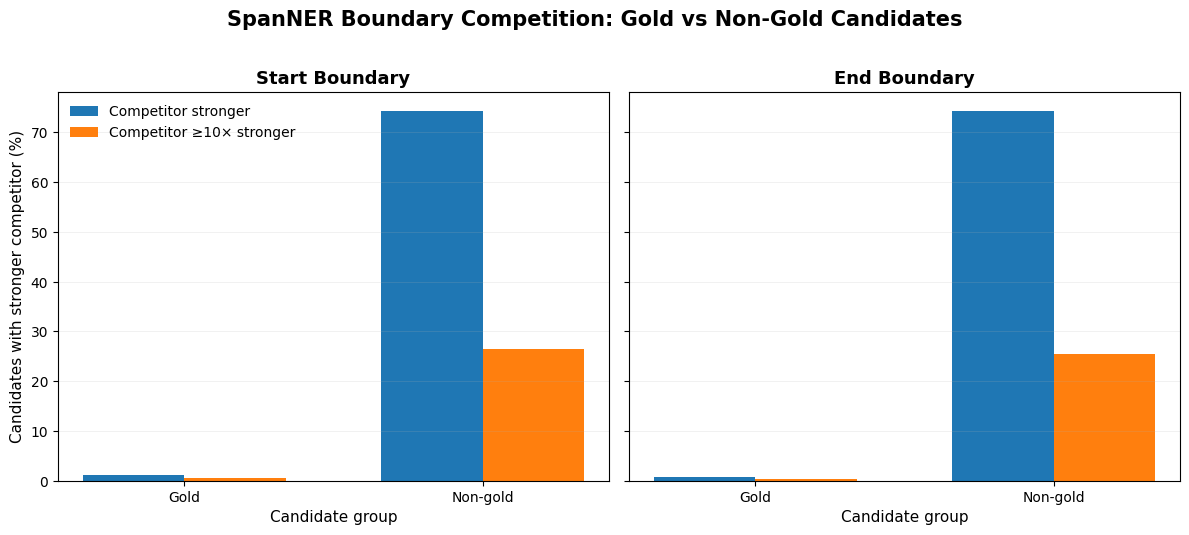

Saved figure: /kaggle/working/06_matched_width_M4_mechanism/figures/spanner_competitor_dominance.png


In [18]:
# Visualise how often the strongest boundary competitor dominates
# gold and non-gold SpanNER candidates.
competition_plot_df = (
    span_competition_semantics_df
    .copy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2),
    sharey=True,
)

bar_width = 0.34

for ax, boundary in zip(
    axes,
    ["Start", "End"],
):
    boundary_df = (
        competition_plot_df.loc[
            competition_plot_df[
                "Boundary"
            ].eq(boundary)
        ]
        .set_index(
            "Candidate Group"
        )
        .reindex(
            ["Gold", "Non-gold"]
        )
    )

    x_positions = np.arange(
        len(boundary_df)
    )

    ax.bar(
        x_positions - bar_width / 2,
        boundary_df[
            "Competitor Stronger (%)"
        ],
        width=bar_width,
        label="Competitor stronger",
    )

    ax.bar(
        x_positions + bar_width / 2,
        boundary_df[
            "Competitor ≥10× Stronger (%)"
        ],
        width=bar_width,
        label="Competitor ≥10× stronger",
    )

    ax.set_xticks(
        x_positions
    )

    ax.set_xticklabels(
        boundary_df.index
    )

    ax.set_title(
        f"{boundary} Boundary",
        fontsize=13,
        fontweight="semibold",
    )

    ax.set_xlabel(
        "Candidate group",
        fontsize=11,
    )

    ax.grid(
        axis="y",
        alpha=0.18,
        linewidth=0.7,
    )

axes[0].set_ylabel(
    "Candidates with stronger competitor (%)",
    fontsize=11,
)

axes[0].legend(
    frameon=False,
)

fig.suptitle(
    "SpanNER Boundary Competition: Gold vs Non-Gold Candidates",
    fontsize=15,
    fontweight="semibold",
    y=1.02,
)

fig.tight_layout()


competition_figure_path = (
    FIGURE_OUTPUT_DIR
    / "spanner_competitor_dominance.png"
)

fig.savefig(
    competition_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved figure:",
    competition_figure_path,
)

## 7. Exploratory M5 Confidence-Gating Diagnostic

The mechanism analysis identified a specific limitation of M4 for SpanNER: large boundary-competition values frequently occur for extremely low-confidence non-gold candidates. Because M4 uses `u` directly to relax the boundary-rank penalty, such candidates can receive substantial score reductions despite having very little model support.

A previously explored diagnostic modification, M5, tested whether adaptive relaxation should also depend on the candidate's own confidence:

$$ a_M5 = (1 − c) + ½[λₛ(1 − cuₛ)Rₛ + λₑ(1 − cuₑ)Rₑ] $$

M5 reuses the already-frozen M4 λ values. No additional λ parameter is selected.

Relative to M4,

$$ a_M4 = (1 − c) + ½[λₛ(1 − uₛ)Rₛ + λₑ(1 − uₑ)Rₑ] $$.

Since $$ 0 ≤ c ≤ 1 $$, multiplying uncertainty by confidence gives $$ cu ≤ u $$. Consequently,

$$ a_M4 ≤ a_M5 ≤ a_fixed $$

for the same candidate and the same λ values.

M5 therefore gives **less adaptive relaxation**, particularly when candidate confidence is small. It directly addresses the mechanism identified in Sections 5–6: a weak candidate should not receive strong relaxation solely because a much stronger neighbouring candidate produces a high competition value.

However, more conservative candidate scores do not guarantee smaller conformal prediction sets. M5 receives its own cross-fitted validation threshold, and the calibrated threshold can increase enough to offset the candidate-level reduction in relaxation.

M5 is evaluated here only as a **validation-only diagnostic on the matched width≤4 candidate support**. It does not replace M4, does not alter the primary M1–M4 specification, and is not propagated to the locked test, robustness or external-replication experiments.

In [19]:
def add_M5_score(
    df,
    model,
):
    """
    Construct exploratory M5 using M4's frozen lambdas.

    M5 gates uncertainty-driven relaxation by the candidate's
    own confidence. No new parameter is fitted.
    """
    result = df.copy()

    params = get_frozen_parameters(
        model,
        "M4",
    )

    lambda_start = float(
        params["lambda_start"]
    )

    lambda_end = float(
        params["lambda_end"]
    )

    c = result[
        "base_confidence"
    ].to_numpy(float)

    base = result[
        "base_nonconformity"
    ].to_numpy(float)

    rs = result[
        "start_rank_penalty"
    ].to_numpy(float)

    re = result[
        "end_rank_penalty"
    ].to_numpy(float)

    us = result[
        "start_uncertainty"
    ].to_numpy(float)

    ue = result[
        "end_uncertainty"
    ].to_numpy(float)

    # Exploratory confidence-gated adaptive score.
    result["score_M5"] = (
        base
        + 0.5
        * (
            lambda_start
            * (1.0 - c * us)
            * rs
            + lambda_end
            * (1.0 - c * ue)
            * re
        )
    )

    # Same-lambda fixed score provides the upper structural bound.
    result["score_fixed_at_M4_lambda"] = (
        base
        + 0.5
        * (
            lambda_start * rs
            + lambda_end * re
        )
    )

    return result


# M5 is evaluated on the common width≤4 validation support.
bert_M5_df = add_M5_score(
    bert_validation_matched_df,
    "BERT",
)

spanner_M5_df = add_M5_score(
    spanner_validation_matched_df,
    "SpanNER",
)


def M5_structure_check(
    df,
    model,
):
    return {
        "Model": model,
        "M4 ≤ M5": bool(
            (
                df["score_M4"]
                <= df["score_M5"] + 1e-12
            ).all()
        ),
        "M5 ≤ Fixed Same-λ": bool(
            (
                df["score_M5"]
                <= df[
                    "score_fixed_at_M4_lambda"
                ] + 1e-12
            ).all()
        ),
        "Mean M5 − M4": float(
            (
                df["score_M5"]
                - df["score_M4"]
            ).mean()
        ),
        "Maximum M5 − M4": float(
            (
                df["score_M5"]
                - df["score_M4"]
            ).max()
        ),
    }


M5_structure_df = pd.DataFrame(
    [
        M5_structure_check(
            bert_M5_df,
            "BERT",
        ),
        M5_structure_check(
            spanner_M5_df,
            "SpanNER",
        ),
    ]
)

print(
    "Table: Structural Effect of Confidence Gating"
)

display(
    M5_structure_df.round(
        {
            "Mean M5 − M4": 6,
            "Maximum M5 − M4": 6,
        }
    )
)

if not (
    M5_structure_df[
        ["M4 ≤ M5", "M5 ≤ Fixed Same-λ"]
    ].to_numpy(bool)
).all():
    raise RuntimeError(
        "M5 structural ordering failed."
    )

print(
    "\nM5 uses new lambda parameters:",
    False,
)

print(
    "M5 promoted to primary method:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Structural Effect of Confidence Gating


,Model,M4 ≤ M5,M5 ≤ Fixed Same-λ,Mean M5 − M4,Maximum M5 − M4
0,BERT,True,True,0.000021,0.004968
1,SpanNER,True,True,0.249600,0.649999



M5 uses new lambda parameters: False
M5 promoted to primary method: False
Official CoNLL test accessed: False


### 7.1 Cross-Fitted Validation Comparison

M4 and M5 are compared using the same five duplicate-safe validation folds used during method development.

For each held-out fold, the remaining 1,300 sentences act as temporary pseudo-calibration data. M4 and M5 each receive their **own finite-sample conformal threshold**, after which representable-gold coverage and mean typed prediction-set size are evaluated on the 325 held-out sentences.

This differs deliberately from the common-threshold diagnostic in Section 5.3. There, the same threshold was used to isolate candidate-level relaxation. Here, each method is recalibrated independently to determine whether confidence gating actually improves the complete conformal coverage–efficiency behaviour.

These remain development diagnostics only and do not replace the independent Notebook-05 conformal-calibration results.

In [20]:
# Attach the already-frozen validation folds.
bert_M5_df = attach_validation_fold(
    bert_M5_df
)

spanner_M5_df = attach_validation_fold(
    spanner_M5_df
)


def evaluate_crossfitted_M4_M5(
    df,
    model,
):
    """Evaluate M4 and exploratory M5 with method-specific q-hats."""
    rows = []

    for held_out_fold in range(5):

        pseudo_calibration_df = df.loc[
            df[FOLD_COLUMN] != held_out_fold
        ]

        held_out_df = df.loc[
            df[FOLD_COLUMN] == held_out_fold
        ]

        if (
            pseudo_calibration_df[
                "sentence_id"
            ].nunique()
            != 1300
        ):
            raise RuntimeError(
                "Unexpected pseudo-calibration population."
            )

        if (
            held_out_df[
                "sentence_id"
            ].nunique()
            != 325
        ):
            raise RuntimeError(
                "Unexpected held-out population."
            )

        for method in [
            "M4",
            "M5",
        ]:
            score_column = (
                f"score_{method}"
            )

            pseudo_gold_scores = (
                sentence_gold_max_scores(
                    pseudo_calibration_df,
                    score_column,
                )
            )

            held_out_gold_scores = (
                sentence_gold_max_scores(
                    held_out_df,
                    score_column,
                )
            )

            for target in TARGET_COVERAGES:

                q_hat, order_rank = (
                    finite_sample_quantile(
                        pseudo_gold_scores.to_numpy(),
                        target,
                    )
                )

                coverage = float(
                    (
                        held_out_gold_scores
                        <= q_hat
                    ).mean()
                )

                mean_set_size = (
                    mean_prediction_set_size(
                        held_out_df,
                        score_column,
                        q_hat,
                    )
                )

                rows.append(
                    {
                        "Model": model,
                        "Held-out Fold": held_out_fold,
                        "Method": method,
                        "Target Coverage": target,
                        "Order Rank": order_rank,
                        "q_hat": q_hat,
                        "Representable-Gold Coverage": coverage,
                        "Mean Typed Set Size": mean_set_size,
                    }
                )

    return pd.DataFrame(
        rows
    )


bert_M5_crossfit_df = (
    evaluate_crossfitted_M4_M5(
        bert_M5_df,
        "BERT",
    )
)

spanner_M5_crossfit_df = (
    evaluate_crossfitted_M4_M5(
        spanner_M5_df,
        "SpanNER",
    )
)

M5_crossfit_fold_df = pd.concat(
    [
        bert_M5_crossfit_df,
        spanner_M5_crossfit_df,
    ],
    ignore_index=True,
)


# Average across the five equal-sized held-out folds.
M5_crossfit_summary_df = (
    M5_crossfit_fold_df
    .groupby(
        [
            "Model",
            "Method",
            "Target Coverage",
        ],
        as_index=False,
    )
    .agg(
        Mean_q_hat=(
            "q_hat",
            "mean",
        ),
        Representable_Gold_Coverage=(
            "Representable-Gold Coverage",
            "mean",
        ),
        Mean_Typed_Set_Size=(
            "Mean Typed Set Size",
            "mean",
        ),
    )
)


print(
    "Table: Exploratory M4–M5 Cross-Fitted Validation Results"
)

display(
    M5_crossfit_summary_df.round(
        {
            "Target Coverage": 2,
            "Mean_q_hat": 6,
            "Representable_Gold_Coverage": 6,
            "Mean_Typed_Set_Size": 4,
        }
    )
)

Table: Exploratory M4–M5 Cross-Fitted Validation Results


,Model,Method,Target Coverage,Mean_q_hat,Representable_Gold_Coverage,Mean_Typed_Set_Size
0,BERT,M4,0.90,0.236419,0.901538,2.5791
1,BERT,M4,0.95,0.767163,0.949538,2.8154
2,BERT,M4,0.99,0.994537,0.990154,8.3243
3,BERT,M5,0.90,0.236419,0.901538,2.5791
4,BERT,M5,0.95,0.767165,0.949538,2.8154
5,BERT,M5,0.99,0.994538,0.990154,8.2634
6,SpanNER,M4,0.90,0.224749,0.899692,1.7545
7,SpanNER,M4,0.95,0.755434,0.948308,1.9674
8,SpanNER,M4,0.99,0.999887,0.990769,14.4474
9,SpanNER,M5,0.90,0.224749,0.899692,1.7545


### Direct M5 − M4 comparison

In [21]:
m4_summary = (
    M5_crossfit_summary_df.loc[
        M5_crossfit_summary_df[
            "Method"
        ].eq("M4")
    ]
    .drop(
        columns="Method"
    )
    .rename(
        columns={
            "Mean_q_hat": "M4 Mean q_hat",
            "Representable_Gold_Coverage": (
                "M4 Coverage"
            ),
            "Mean_Typed_Set_Size": (
                "M4 Mean Set Size"
            ),
        }
    )
)

m5_summary = (
    M5_crossfit_summary_df.loc[
        M5_crossfit_summary_df[
            "Method"
        ].eq("M5")
    ]
    .drop(
        columns="Method"
    )
    .rename(
        columns={
            "Mean_q_hat": "M5 Mean q_hat",
            "Representable_Gold_Coverage": (
                "M5 Coverage"
            ),
            "Mean_Typed_Set_Size": (
                "M5 Mean Set Size"
            ),
        }
    )
)


M5_comparison_df = (
    m4_summary.merge(
        m5_summary,
        on=[
            "Model",
            "Target Coverage",
        ],
        validate="one_to_one",
    )
)


M5_comparison_df[
    "Δ q_hat (M5−M4)"
] = (
    M5_comparison_df[
        "M5 Mean q_hat"
    ]
    - M5_comparison_df[
        "M4 Mean q_hat"
    ]
)

M5_comparison_df[
    "Δ Coverage (M5−M4)"
] = (
    M5_comparison_df[
        "M5 Coverage"
    ]
    - M5_comparison_df[
        "M4 Coverage"
    ]
)

M5_comparison_df[
    "Δ Set Size (M5−M4)"
] = (
    M5_comparison_df[
        "M5 Mean Set Size"
    ]
    - M5_comparison_df[
        "M4 Mean Set Size"
    ]
)


print(
    "Table: Effect of Confidence Gating Relative to M4"
)

display(
    M5_comparison_df.round(
        {
            "Target Coverage": 2,
            "M4 Mean q_hat": 6,
            "M5 Mean q_hat": 6,
            "Δ q_hat (M5−M4)": 6,
            "M4 Coverage": 6,
            "M5 Coverage": 6,
            "Δ Coverage (M5−M4)": 6,
            "M4 Mean Set Size": 4,
            "M5 Mean Set Size": 4,
            "Δ Set Size (M5−M4)": 4,
        }
    )
)


observed_M5_order_ranks = (
    M5_crossfit_fold_df[
        [
            "Target Coverage",
            "Order Rank",
        ]
    ]
    .drop_duplicates()
    .set_index(
        "Target Coverage"
    )["Order Rank"]
    .to_dict()
)

expected_M5_order_ranks = {
    0.90: 1171,
    0.95: 1236,
    0.99: 1288,
}

if (
    observed_M5_order_ranks
    != expected_M5_order_ranks
):
    raise RuntimeError(
        "Unexpected M5 cross-fitted order ranks."
    )


print(
    "\nM5 uses method-specific cross-fitted thresholds:",
    True,
)

print(
    "M5 lambda retuning performed:",
    False,
)

print(
    "M5 propagated downstream:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

Table: Effect of Confidence Gating Relative to M4


,Model,Target Coverage,M4 Mean q_hat,M4 Coverage,M4 Mean Set Size,M5 Mean q_hat,M5 Coverage,M5 Mean Set Size,Δ q_hat (M5−M4),Δ Coverage (M5−M4),Δ Set Size (M5−M4)
0,BERT,0.90,0.236419,0.901538,2.5791,0.236419,0.901538,2.5791,0.000000,0.000000,0.0000
1,BERT,0.95,0.767163,0.949538,2.8154,0.767165,0.949538,2.8154,0.000001,0.000000,0.0000
2,BERT,0.99,0.994537,0.990154,8.3243,0.994538,0.990154,8.2634,0.000001,0.000000,-0.0609
3,SpanNER,0.90,0.224749,0.899692,1.7545,0.224749,0.899692,1.7545,0.000000,0.000000,0.0000
4,SpanNER,0.95,0.755434,0.948308,1.9674,0.760226,0.948308,1.9545,0.004792,0.000000,-0.0129
5,SpanNER,0.99,0.999887,0.990769,14.4474,1.150671,0.989538,60.3342,0.150784,-0.001231,45.8868



M5 uses method-specific cross-fitted thresholds: True
M5 lambda retuning performed: False
M5 propagated downstream: False
Official CoNLL test accessed: False


### 7.2 Confidence Gating Does Not Reliably Improve Conformal Efficiency

M5 behaved as intended at candidate level. For both architectures,

$$a_M4 ≤ a_M5 ≤ a_fixed$$

held for every candidate, confirming that confidence gating consistently reduces the amount of uncertainty-driven relaxation.

For BERT, however, the modification had almost no practical effect because the original M4 relaxation was already extremely small. M4 and M5 were identical at the 90% and 95% operating points. At 99%, M5 reduced mean set size only slightly, from 8.32 to 8.26 candidates per sentence, with unchanged representable-gold coverage.

SpanNER showed a mixed result. At 90%, M4 and M5 were identical. At 95%, confidence gating produced a small efficiency improvement, reducing mean set size from 1.97 to 1.95 while preserving the same empirical coverage.

The behaviour reversed sharply at 99%. Although M5 gives every candidate a score at least as conservative as M4, its independently calibrated mean threshold increased from approximately 1.000 to 1.150. The resulting mean prediction-set size increased from 14.45 for M4 to 60.33 for M5, while representable-gold coverage decreased slightly from 0.9908 to 0.9895.

This illustrates an important conformal effect: making candidate scores individually more conservative does not guarantee smaller prediction sets once the method is recalibrated. The final set depends jointly on the score transformation and its corresponding conformal threshold.

M5 therefore does not provide a reliable solution to the M4 efficiency problem. It is retained as an informative negative diagnostic rather than promoted to a fifth primary conformal method. No further score variants are developed after this analysis.

## 8. Mechanism Conclusions and Final Handoff

Notebook 06 performed targeted post-hoc analyses of the frozen conformal experiment without modifying the primary M1–M4 specification.

The matched-width control first removed the architectural difference in candidate support by restricting BERT to spans of width ≤4 and recomputing its candidate-local boundary ranks and conformal thresholds. BERT prediction sets became smaller, particularly at 99% coverage, confirming that its larger native candidate universe contributes to high-coverage set size. However, SpanNER's substantially larger M2–M4 sets remained unchanged. Candidate-width asymmetry therefore does not explain the SpanNER M4 behaviour.

The subsequent mechanism analysis isolated uncertainty adaptation using a fixed-λ counterfactual. BERT's uncertainty-driven score reductions were numerically negligible. SpanNER, in contrast, received substantial adaptive relaxation, with a mean candidate-level score reduction of approximately 0.25.

This relaxation was overwhelmingly concentrated on non-gold candidates. SpanNER gold candidates had mean confidence of approximately 0.932 and received little adaptive relaxation, whereas non-gold candidates had mean confidence below 0.001 and received mean relaxation of approximately 0.252. Almost all aggregate adaptive relaxation was therefore assigned to the non-gold population.

The boundary-competition analysis explained why. Approximately three quarters of SpanNER non-gold candidates were weaker than their strongest local boundary competitor, and approximately one quarter were dominated by at least a factor of ten. High boundary competition therefore frequently represented domination by a stronger neighbouring span rather than a close contest between similarly plausible alternatives.

The common-threshold diagnostic connected this property directly to prediction-set expansion. At the 99% operating point, applying the adaptive M4 score at the same fixed threshold admitted more than 200,000 additional validation candidates, almost all non-gold and extremely low-confidence.

Finally, the exploratory M5 confidence-gating diagnostic reduced candidate-level relaxation as designed but did not reliably improve conformal efficiency after recalibration. In particular, SpanNER M5 produced substantially larger prediction sets at 99% coverage. M5 is therefore retained only as a negative diagnostic.

Together, these analyses explain why informative boundary-competition signals do not automatically translate into improved conformal efficiency. The principal issue is not candidate-space width or failure of the uncertainty signal to measure local competition. Rather, the direct multiplicative use of competition strength in M4 can strongly relax weak candidates when a neighbouring candidate dominates them.

No primary method definitions, λ values or downstream conformal specifications are changed as a consequence of this notebook.

**Official CoNLL-2003 test status:** locked and unaccessed.

### 8.1 Saved Diagnostic Artefacts

The final notebook exports the matched-width control results and the principal mechanism diagnostics required for reproducibility and dissertation reporting.

These outputs are descriptive extensions of the frozen Notebook-05 conformal experiment. They do not replace the primary conformal specification.

In [22]:
RESULTS_OUTPUT_DIR = (
    OUTPUT_ROOT / "results"
)

CONFIG_OUTPUT_DIR = (
    OUTPUT_ROOT / "configuration"
)

RESULTS_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONFIG_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Matched-width conformal control.
matched_width_quantiles_path = (
    RESULTS_OUTPUT_DIR
    / "matched_width4_conformal_quantiles.csv"
)

matched_width_results_path = (
    RESULTS_OUTPUT_DIR
    / "matched_width4_coverage_efficiency.csv"
)

rank_effect_path = (
    RESULTS_OUTPUT_DIR
    / "matched_width4_rank_recomputation.csv"
)


matched_width_quantiles_df.to_csv(
    matched_width_quantiles_path,
    index=False,
)

matched_width_operating_results_df.to_csv(
    matched_width_results_path,
    index=False,
)

rank_recomputation_summary_df.to_csv(
    rank_effect_path,
    index=False,
)


# M4 mechanism diagnostics.
relaxation_summary_path = (
    RESULTS_OUTPUT_DIR
    / "M4_relaxation_summary.csv"
)

gold_non_gold_path = (
    RESULTS_OUTPUT_DIR
    / "M4_gold_non_gold_mechanism.csv"
)

common_threshold_path = (
    RESULTS_OUTPUT_DIR
    / "M4_common_threshold_diagnostic.csv"
)

competition_semantics_path = (
    RESULTS_OUTPUT_DIR
    / "spanner_competition_semantics.csv"
)


m4_relaxation_summary_df.to_csv(
    relaxation_summary_path,
    index=False,
)

gold_non_gold_relaxation_df.to_csv(
    gold_non_gold_path,
    index=False,
)

common_threshold_summary_df.to_csv(
    common_threshold_path,
    index=False,
)

span_competition_semantics_df.to_csv(
    competition_semantics_path,
    index=False,
)


# Exploratory M5 diagnostic.
M5_comparison_path = (
    RESULTS_OUTPUT_DIR
    / "exploratory_M5_vs_M4_validation.csv"
)

M5_structure_path = (
    RESULTS_OUTPUT_DIR
    / "exploratory_M5_structural_effect.csv"
)


M5_comparison_df.to_csv(
    M5_comparison_path,
    index=False,
)

M5_structure_df.to_csv(
    M5_structure_path,
    index=False,
)


# Record the scientific status of the notebook explicitly.
mechanism_specification = {
    "status": "MATCHED_WIDTH_AND_M4_MECHANISM_ANALYSIS_COMPLETE",

    "source_primary_specification": (
        "Notebook 05 frozen M1-M4 conformal specification"
    ),

    "matched_width_control": {
        "maximum_width": MATCHED_MAX_WIDTH,
        "lambda_retuned": False,
        "bert_boundary_ranks_recomputed": True,
        "spanner_native_support_unchanged": True,
    },

    "mechanism_analysis": {
        "population": (
            "architecture-native validation candidates"
        ),
        "fixed_lambda_counterfactual_used": True,
        "m4_relaxation_definition": (
            "0.5 * "
            "(lambda_start*u_start*R_start + "
            "lambda_end*u_end*R_end)"
        ),
        "binary_correctness_calibrators_used": False,
        "mc_dropout_used": False,
    },

    "M5": {
        "status": "exploratory_negative_diagnostic",
        "new_lambda_parameters": False,
        "promoted_to_primary_method": False,
        "propagated_downstream": False,
    },

    "primary_M1_M4_modified": False,
    "lambda_retuning_permitted": False,
    "official_test_accessed": False,

    "next_notebook": (
        "07_Controlled_Noise_Robustness"
    ),
}


mechanism_specification_path = (
    CONFIG_OUTPUT_DIR
    / "mechanism_analysis_specification.json"
)

with mechanism_specification_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        mechanism_specification,
        file,
        indent=2,
    )


completion_record = {
    "notebook": (
        "06_Matched_Width_and_M4_Mechanism_Analysis"
    ),
    "status": "COMPLETE",
    "matched_width_control_complete": True,
    "M4_mechanism_analysis_complete": True,
    "SpanNER_competition_analysis_complete": True,
    "M5_diagnostic_complete": True,
    "primary_M1_M4_modified": False,
    "lambda_retuning_performed": False,
    "official_test_accessed": False,
    "next_notebook": (
        "07_Controlled_Noise_Robustness"
    ),
}


completion_record_path = (
    OUTPUT_ROOT
    / "completion_record.json"
)

with completion_record_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=2,
    )


export_summary_df = pd.DataFrame(
    [
        {
            "Artefact": "Matched-width quantiles",
            "File": matched_width_quantiles_path.name,
        },
        {
            "Artefact": "Matched-width coverage–efficiency",
            "File": matched_width_results_path.name,
        },
        {
            "Artefact": "Boundary-rank recomputation",
            "File": rank_effect_path.name,
        },
        {
            "Artefact": "M4 relaxation summary",
            "File": relaxation_summary_path.name,
        },
        {
            "Artefact": "Gold vs non-gold mechanism",
            "File": gold_non_gold_path.name,
        },
        {
            "Artefact": "Common-threshold diagnostic",
            "File": common_threshold_path.name,
        },
        {
            "Artefact": "SpanNER competition semantics",
            "File": competition_semantics_path.name,
        },
        {
            "Artefact": "Exploratory M5 comparison",
            "File": M5_comparison_path.name,
        },
        {
            "Artefact": "Mechanism specification",
            "File": mechanism_specification_path.name,
        },
        {
            "Artefact": "Completion record",
            "File": completion_record_path.name,
        },
    ]
)


print(
    "Table: Final Notebook 06 Handoff"
)

display(
    export_summary_df
)

print(
    "\nNotebook 06 complete:",
    True,
)

print(
    "Primary M1-M4 specification modified:",
    False,
)

print(
    "Lambda retuning performed:",
    False,
)

print(
    "M5 promoted downstream:",
    False,
)

print(
    "Official CoNLL test accessed:",
    False,
)

print(
    "Next notebook:",
    "07_Controlled_Noise_Robustness",
)

Table: Final Notebook 06 Handoff


,Artefact,File
0,Matched-width quantiles,matched_width4_conformal_quantiles.csv
1,Matched-width coverage–efficiency,matched_width4_coverage_efficiency.csv
2,Boundary-rank recomputation,matched_width4_rank_recomputation.csv
3,M4 relaxation summary,M4_relaxation_summary.csv
4,Gold vs non-gold mechanism,M4_gold_non_gold_mechanism.csv
5,Common-threshold diagnostic,M4_common_threshold_diagnostic.csv
6,SpanNER competition semantics,spanner_competition_semantics.csv
7,Exploratory M5 comparison,exploratory_M5_vs_M4_validation.csv
8,Mechanism specification,mechanism_analysis_specification.json
9,Completion record,completion_record.json



Notebook 06 complete: True
Primary M1-M4 specification modified: False
Lambda retuning performed: False
M5 promoted downstream: False
Official CoNLL test accessed: False
Next notebook: 07_Controlled_Noise_Robustness
